# Ghigliottina — Analisi modelli locali

Analizza i 3 fogli `T_0.0`/`T_0.3`/`T_0.7` (solo modelli locali — i modelli
commerciali hanno un disegno di raccolta diverso, run singolo e parametri
non controllati, e vanno analizzati a parte, non in questo notebook).

Rilancia questo notebook ogni volta che aggiungi nuovi dati (altra sessione,
altri modelli, valutazione manuale più completa) — nessuna cella salva
uno stato intermedio, riparte sempre dai file Excel.

In [127]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 40)

## Configurazione

`RESULT_FILES` accetta più file: utile se hai sessioni ancora separate
(es. la Sessione 1 in un file e uno smoke test di modelli nuovi in un
altro) prima di averle consolidate in un unico `ghigliottina_results.xlsx`.
Se un item duplicato (stesso modello, stesso prompt, stessa temperatura)
compare in più file, viene tenuta la prima occorrenza e stampato un avviso
— non sparisce in silenzio.

In [128]:
RESULT_FILES = [r"D:\guillotine\guillotine\source\complete_ghigliottina_results.xlsx"]

RUN_SHEETS = ["T_0.0", "T_0.3", "T_0.7"]
EXPECTED_PROMPTS_PER_TEMP = 30

# Stessa lista di config.py - se la aggiorni li', copiala anche qui.
# è stata aggiornata solo qui, nel grafico dovrebbero vedersi oltre 30 modelli, ma non ci sono tutti
REASONING_MODEL_MARKERS = [ "aion-labs/aion-3.0-mini",
                            "arcee-ai/trinity-large-thinking",
                            "bytedance-seed/seed-1.6-flash",
                            "bytedance-seed/seed-2-1-turbo",
                            "deepseek/deepseek-v3.2",
                            "deepseek/deepseek-v4-flash-0731",
                            "inclusionai/ling-3.0-flash",
                            "inclusionai/ring-2.6-1t",
                            "lfm2.5:8b",
                            "moonshotai/kimi-k2.5",
                            "nex-agi/nex-n2-mini",
                            "nex-agi/nex-n2-pro",
                            "nvidia/nemotron-3-ultra-550b-a55b",
                            "nvidia/nemotron-3.5-lightning:free",
                            "nvidia/nemotron-nano-9b-v2:free",
                            "qwen/qwen3-235b-a22b-thinking-2507",
                            "qwen/qwen3-32b",
                            "qwen/qwen3-next-80b-a3b-thinking",
                            "qwen/qwen3.7-flash",
                            "qwen/qwen3.7-plus",
                            "stepfun/step-3.5-flash",
                            "stepfun/step-3.7-flash",
                            "tencent/hunyuan-a13b-instruct",
                            "tencent/hy3",
                            "thinkingmachines/inkling-small",
                            "xiaomi/mimo-v2.5",
                            "xiaomi/mimo-v2.5-pro",
                            "z-ai/glm-4.5-air",
                            "z-ai/glm-4.6v",
                            "z-ai/glm-4.7",
                            "z-ai/glm-4.7-flash",
                            "z-ai/glm-5.2:free",
                            "deepseek-r1",
                            "qwq",
                            "gpt-oss",
                            "qwen3.5",
                            "gemma4:12b",
                            "qwen3:14b",
                            "starcoder2:15b-instruct"]

# Dimensione approssimata in miliardi di parametri, dove non ricavabile dal tag.
MANUAL_SIZE_OVERRIDES_B = ({
    "nemotron-3-nano:4b": 4.0,
    "gemma4:e4b": 4.0,  # effective ~4B (dichiarato dal produttore)
    "nous-hermes2:latest": 10.7,  # Nous-Hermes-2-Solar
    "phi3.5:latest": 3.8,  # Phi-3.5-mini
    "phi3:mini": 3.8,  # Phi-3-mini
})

# Verificati su model card/technical report ufficiali (agosto 2026).
# Formato: {"total": ..., "active": ...} - active = total per i modelli densi.
OPENROUTER_VERIFIED_PARAMS_B = {
    "deepseek/deepseek-r1-0528":              {"total": 671.0, "active": 37.0},
    "deepseek/deepseek-v3.2":                 {"total": 671.0, "active": 37.0},  # stessa architettura V3, non confermato esplicitamente per questa versione
    "moonshotai/kimi-k2.5":                   {"total": 1000.0, "active": 32.0},
    "inclusionai/ring-2.6-1t":                {"total": 1000.0, "active": None},  # "1t" esplicito nel nome, attivi non trovati
    "inclusionai/ling-2.6-1t":                {"total": 1000.0, "active": None},
    "z-ai/glm-4.5-air":                       {"total": 106.0, "active": 12.0},
    "thinkingmachines/inkling-small":         {"total": 276.0, "active": 12.0},
    "meta-llama/llama-4-maverick":            {"total": 400.0, "active": 17.0},
    "meta-llama/llama-4-scout":               {"total": 109.0, "active": 17.0},
    "cohere/command-r-plus-08-2024":          {"total": 104.0, "active": 104.0},
    "cohere/command-r-08-2024":               {"total": 35.0, "active": 35.0},
}

# Cercati ma senza un conteggio dichiarato pubblicamente reperibile - non
# indovinato, lasciato fuori. La maggior parte del catalogo OpenRouter non
# dichiara i parametri (verificato in una sessione precedente: circa 29 su
# 417 modelli totali lo fanno) - non e' un buco di ricerca, e' un limite
# strutturale di cosa i produttori pubblicano:
# z-ai/glm-5.2:free, z-ai/glm-4.7, z-ai/glm-4.6v, z-ai/glm-4.7-flash,
# stepfun/step-3.5-flash, stepfun/step-3.7-flash,
# bytedance-seed/seed-2-1-turbo, bytedance-seed/seed-1.6-flash,
# xiaomi/mimo-v2.5, xiaomi/mimo-v2.5-pro,
# qwen/qwen3.7-plus, qwen/qwen3.7-flash,
# deepseek/deepseek-v4-flash-0731,
# nex-agi/nex-n2-pro, nex-agi/nex-n2-mini,
# tencent/hy3, aion-labs/aion-3.0-mini,
# nvidia/nemotron-3.5-lightning:free,
# arcee-ai/trinity-large-thinking,
# mistralai/mistral-medium-3.1, mistralai/mistral-saba,
# upstage/solar-pro4, inclusionai/ling-3.0-flash, inclusionai/ling-2.6-flash,
# amazon/nova-micro-v1, amazon/nova-2-lite-v1,
# openai/gpt-3.5-turbo, openai/gpt-4o-mini,  # OpenAI non dichiara mai i parametri
# ibm-granite/granite-4.0-h-micro


def parse_size_billion(model_tag: str) -> float | None:
    """Estrae la dimensione in miliardi di parametri dal tag (es. '7b', '1.6b', '345m')."""
    if model_tag in MANUAL_SIZE_OVERRIDES_B:
        return MANUAL_SIZE_OVERRIDES_B[model_tag]
    m = re.search(r"(\d+(?:\.\d+)?)\s*b\b", model_tag.lower())
    if m:
        return float(m.group(1))
    m = re.search(r"(\d+(?:\.\d+)?)\s*m\b", model_tag.lower())
    if m:
        return float(m.group(1)) / 1000.0
    return None


def is_reasoning_model(model_name: str) -> bool:
    return any(marker in model_name.lower() for marker in REASONING_MODEL_MARKERS)

## Caricamento dati

Legge i 3 fogli da ciascun file, aggiunge la colonna `temperature`
(ricavata dal nome dello sheet), e gestisce la compatibilità con file
scritti prima che `duration_s`/`status`/`is_clue_echo` esistessero nello
schema (li riempie con un default neutro invece di fallire).

In [129]:
def load_results(paths: list[str]) -> pd.DataFrame:
    frames = []
    for path in paths:
        path = Path(path)
        if not path.exists():
            warnings.warn(f"File non trovato, saltato: {path}")
            continue
        for sheet in RUN_SHEETS:
            df = pd.read_excel(path, sheet_name=sheet, engine="openpyxl")
            if df.empty:
                continue
            df["temperature"] = float(sheet.replace("T_", ""))
            df["source_file"] = path.name
            frames.append(df)

    if not frames:
        raise ValueError("Nessun dato caricato - controlla RESULT_FILES")

    data = pd.concat(frames, ignore_index=True)

    for col, default in [("status", "ok"), ("is_clue_echo", 0), ("is_first_call", 0), ("duration_s", np.nan)]:
        if col not in data.columns:
            data[col] = default
    data["status"] = data["status"].fillna("ok")

    dup_mask = data.duplicated(subset=["model_name", "prompt_id", "temperature"], keep="first")
    if dup_mask.any():
        dups = data.loc[dup_mask, ["model_name", "prompt_id", "temperature", "source_file"]]
        warnings.warn(
            f"{dup_mask.sum()} righe duplicate su (model, prompt, temperature) - "
            f"tenuta la prima occorrenza. Esempio:\n{dups.head()}"
        )
        data = data.loc[~dup_mask].copy()

    data["is_reasoning_model"] = data["model_name"].apply(is_reasoning_model)
    return data


data = load_results(RESULT_FILES)
print(f"Righe totali caricate: {len(data)}")
print(f"Modelli: {data['model_name'].nunique()}")
data.head()

Righe totali caricate: 9908
Modelli: 111


C:\Users\PC\AppData\Local\Temp\ipykernel_12564\3283526459.py:29: UserWarning: 270 righe duplicate su (model, prompt, temperature) - tenuta la prima occorrenza. Esempio:
                         model_name  prompt_id  temperature  \
849  Hudson/gpt2-instruct:345m-q8_0  guillo_01          0.0   
851  Hudson/gpt2-instruct:345m-q8_0  guillo_02          0.0   
853  Hudson/gpt2-instruct:345m-q8_0  guillo_03          0.0   
855  Hudson/gpt2-instruct:345m-q8_0  guillo_04          0.0   
857  Hudson/gpt2-instruct:345m-q8_0  guillo_05          0.0   

                            source_file  
849  complete_ghigliottina_results.xlsx  
851  complete_ghigliottina_results.xlsx  
853  complete_ghigliottina_results.xlsx  
855  complete_ghigliottina_results.xlsx  
857  complete_ghigliottina_results.xlsx  
  warnings.warn(


,model_name,prompt_id,word1,word2,word3,word4,word5,expected_solution,raw_response,predicted_word,...,synonym_manual,coherence_manual,timestamp,difficulty_note,duration_s,is_first_call,status,temperature,source_file,is_reasoning_model
0,aion-labs/aion-3.0-mini,guillo_01,gluteus,adjustable,sit,office,kitchen,chair,<think>I must not include any extraneous text....,CHAIR,...,0,0,2026-08-26 20:17:42,easy,11.6,0,ok,0.0,complete_ghigliottina_results.xlsx,True
1,aion-labs/aion-3.0-mini,guillo_02,highway,wheel,transport,fuel,insurance,car,<think>I must not include any ethical consider...,CAR,...,0,0,2026-08-26 20:17:48,easy,5.4,0,ok,0.0,complete_ghigliottina_results.xlsx,True
2,aion-labs/aion-3.0-mini,guillo_03,Washington,skyscraper,sewer,courthouse,shop,city,<think>I must not include any additional text ...,BUILDING,...,0,0,2026-08-26 20:24:00,medium,370.7,0,ok,0.0,complete_ghigliottina_results.xlsx,True
3,aion-labs/aion-3.0-mini,guillo_04,Pascal,inch,stress,cloud,blood,pressure,<think>I must not include any ethical consider...,PRESSURE,...,0,0,2026-08-26 20:30:50,medium,409.8,0,ok,0.0,complete_ghigliottina_results.xlsx,True
4,aion-labs/aion-3.0-mini,guillo_05,moon,speed,lamp,hope,visible,light,<think>I must not include any extraneous text ...,LIGHT,...,0,0,2026-08-26 20:30:58,medium,6.9,0,ok,0.0,complete_ghigliottina_results.xlsx,True


## Controllo di copertura

Prima di fidarti di qualunque grafico sotto: quanti modelli hanno
davvero tutte le 90 righe attese (30 prompt × 3 temperature)? E quanti
timeout per modello — un timeout non è un dato mancante a caso, è "non
ha risposto entro il tempo limite", va guardato insieme all'accuratezza,
non nascosto.

In [130]:
coverage = data.groupby("model_name").size().rename("righe_totali")
expected = EXPECTED_PROMPTS_PER_TEMP * len(RUN_SHEETS)
incomplete = coverage[coverage < expected]

print(f"Copertura attesa per modello: {expected} righe")
if len(incomplete):
    print(f"\nModelli con copertura incompleta ({len(incomplete)}):")
    print(incomplete)
else:
    print("Copertura completa su tutti i modelli.")

status_counts = data.groupby(["model_name", "status"]).size().unstack(fill_value=0)
status_counts

Copertura attesa per modello: 90 righe

Modelli con copertura incompleta (1):
model_name
arcee-ai/virtuoso-large    8
Name: righe_totali, dtype: int64


status,error,ok,timeout
model_name,,,
Hudson/gpt2-instruct:345m-q8_0,0,90,0
aion-labs/aion-3.0-mini,0,90,0
allenai/olmo-3-32b-think,90,0,0
amazon/nova-2-lite-v1,0,90,0
amazon/nova-micro-v1,0,90,0
...,...,...,...
z-ai/glm-4.6v,0,90,0
z-ai/glm-4.7,2,88,0
z-ai/glm-4.7-flash,0,90,0


## RQ1 / RQ2 — Classifica per accuratezza

`exact_match`, `same_root`, `is_similar_lev` sono le tre metriche
automatiche; `is_clue_echo` e `format_compliant` non sono accuratezza in
sé ma aiutano a interpretarla (un modello con `exact_match` basso ma
anche `is_clue_echo` alto sta fallendo diversamente da uno con
`is_clue_echo` basso). Da qui in avanti si lavora solo su `status="ok"`
— i timeout non hanno una risposta da valutare.

In [192]:
from statsmodels.stats.proportion import proportion_confint

ok_data = data[data["status"] == "ok"].copy()

leaderboard = ok_data.groupby("model_name").agg(
    n=("exact_match", "size"),
    exact_match=("exact_match", "mean"),
    same_root=("same_root", "mean"),
    is_similar_lev=("is_similar_lev", "mean"),
    format_compliant=("format_compliant", "mean"),
    is_clue_echo=("is_clue_echo", "mean"),
    levenshtein_mean=("levenshtein_normalized", "mean"),
).sort_values("exact_match", ascending=False)

successes = (leaderboard["exact_match"] * leaderboard["n"]).round().astype(int)
leaderboard["ci_low"], leaderboard["ci_high"] = proportion_confint(
    successes, leaderboard["n"], method="wilson"
)

top10 = leaderboard.head(250)
top10.round(3)


,n,exact_match,same_root,is_similar_lev,format_compliant,is_clue_echo,levenshtein_mean,ci_low,ci_high
model_name,,,,,,,,,
z-ai/glm-5.2:free,4,0.750,0.750,0.750,0.750,0.000,0.250,0.301,0.954
stepfun/step-3.5-flash,90,0.711,0.778,0.778,0.978,0.000,0.218,0.610,0.795
bytedance-seed/seed-2-1-turbo,90,0.678,0.744,0.744,1.000,0.000,0.235,0.576,0.765
nvidia/nemotron-3-ultra-550b-a55b,90,0.678,0.744,0.744,0.922,0.000,0.243,0.576,0.765
moonshotai/kimi-k2.5,89,0.663,0.730,0.730,0.944,0.000,0.247,0.560,0.753
...,...,...,...,...,...,...,...,...,...
Hudson/gpt2-instruct:345m-q8_0,90,0.000,0.022,0.033,0.011,0.700,0.846,0.000,0.041
meta-llama/llama-3.2-1b-instruct,90,0.000,0.000,0.000,0.978,0.189,0.867,0.000,0.041
granite4:350m,90,0.000,0.000,0.000,1.000,0.611,0.893,0.000,0.041


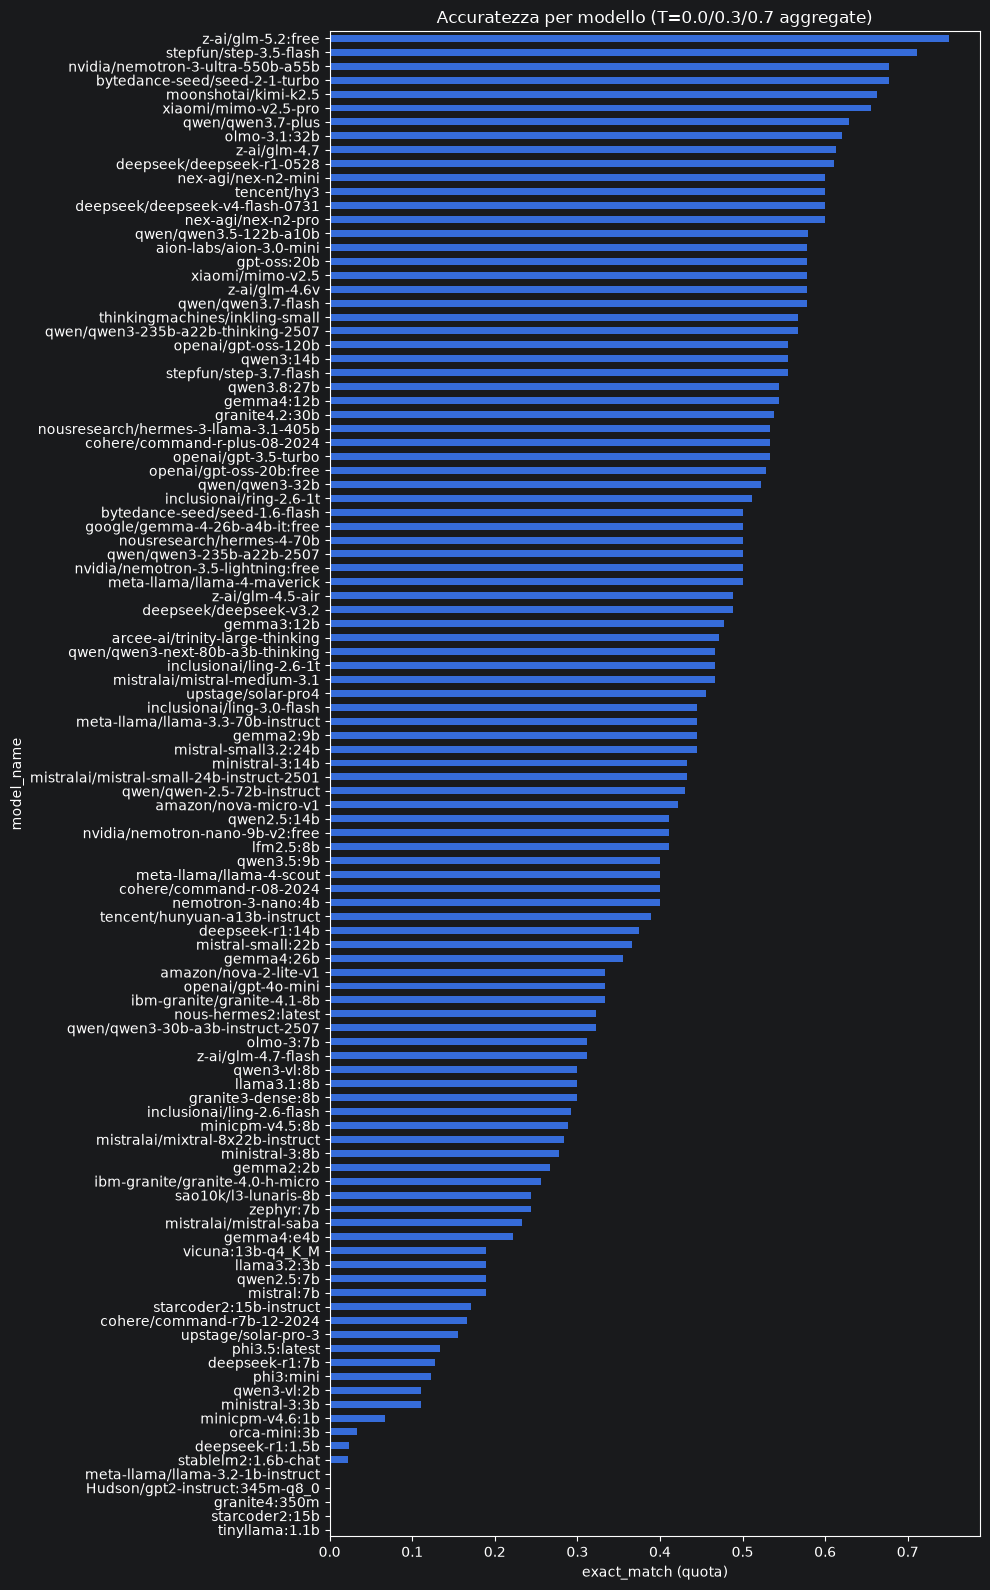

In [132]:
fig, ax = plt.subplots(figsize=(10, 16))
leaderboard["exact_match"].sort_values().plot.barh(ax=ax)
ax.set_xlabel("exact_match (quota)")
ax.set_title("Accuratezza per modello (T=0.0/0.3/0.7 aggregate)")
plt.tight_layout()
plt.show()

## RQ3 — Sinonimi e coerenza (valutazione manuale)

Queste due colonne le compili tu a mano, quindi qui sotto la prima cosa
da guardare è **quanto è completa la revisione**, non il tasso finale —
un tasso su un 20% di righe revisionate non è ancora un numero da
riportare nel whitepaper.

In [133]:
for col in ["synonym_manual", "coherence_manual"]:
    reviewed = ok_data[col].notna().sum()
    total = len(ok_data)
    print(f"{col}: {reviewed}/{total} righe valutate ({100*reviewed/total:.0f}%)")

    if reviewed:
        reviewed_data = ok_data[ok_data[col].notna()]
        rate = reviewed_data.groupby("model_name")[col].mean().sort_values(ascending=False)
        print(f"Tasso sulle righe valutate finora, prime 5:\n{rate.head()}\n")

synonym_manual: 9380/9380 righe valutate (100%)
Tasso sulle righe valutate finora, prime 5:
model_name
gemma2:9b             0.144444
minicpm-v4.5:8b       0.133333
gemma3:12b            0.133333
gemma4:e4b            0.133333
nemotron-3-nano:4b    0.122222
Name: synonym_manual, dtype: float64

coherence_manual: 9380/9380 righe valutate (100%)
Tasso sulle righe valutate finora, prime 5:
model_name
gemma3:12b                         0.233333
ibm-granite/granite-4.0-h-micro    0.211111
minicpm-v4.5:8b                    0.211111
gemma4:e4b                         0.200000
sao10k/l3-lunaris-8b               0.177778
Name: coherence_manual, dtype: float64



## RQ4 — Sensibilità alla temperatura (solo locali)

Per costruzione, questa sezione ha senso solo qui — i modelli commerciali
non hanno un asse di temperatura su cui posizionarsi (run singolo,
parametri non controllati).

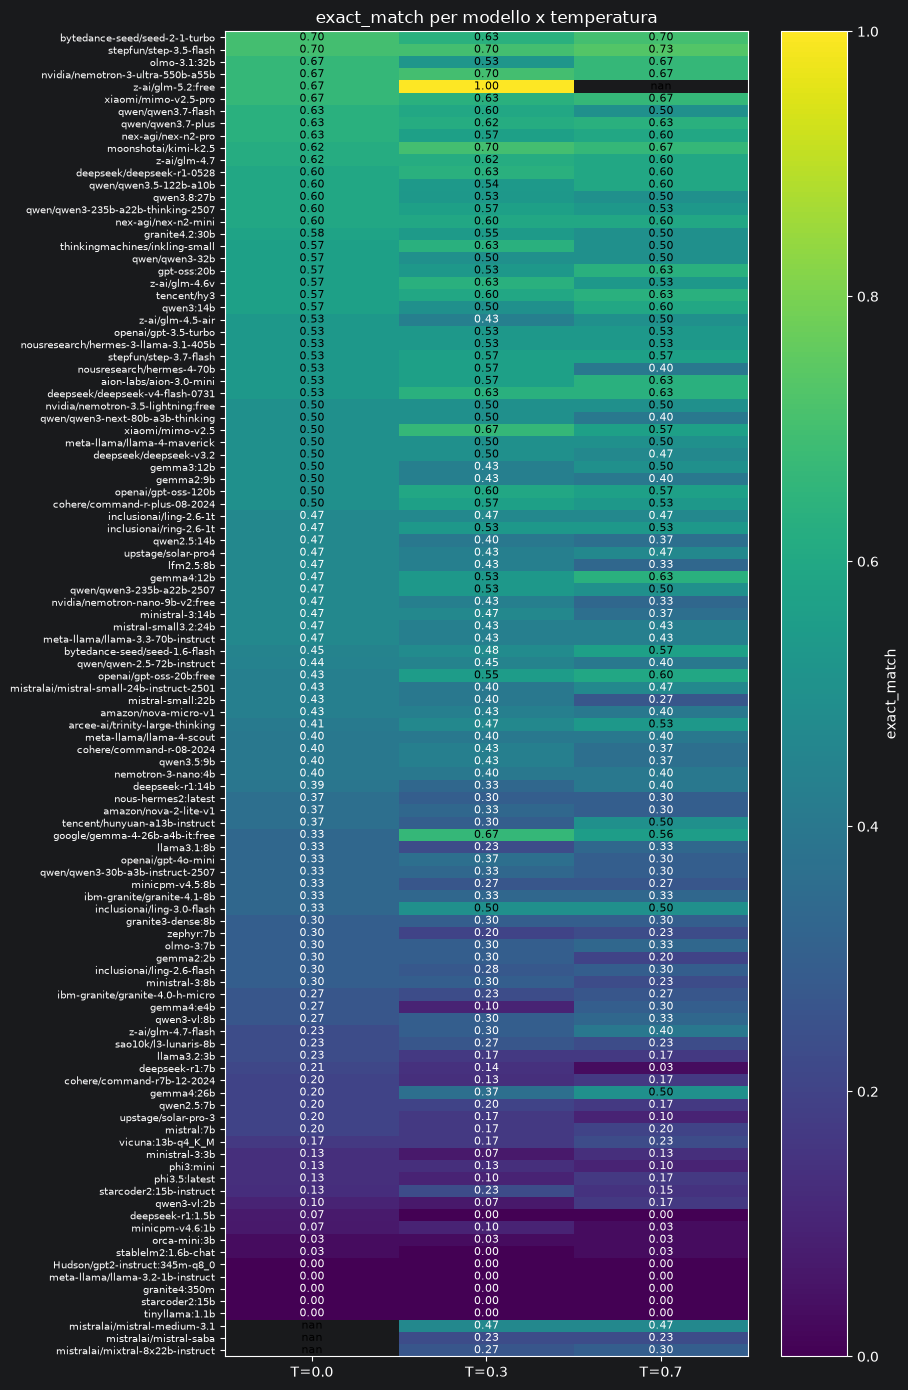

In [134]:
temp_pivot = ok_data.pivot_table(
    index="model_name", columns="temperature", values="exact_match", aggfunc="mean"
).sort_values(0.0, ascending=False)

fig, ax = plt.subplots(figsize=(9, 14))
im = ax.imshow(temp_pivot.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(temp_pivot.columns)))
ax.set_xticklabels([f"T={t}" for t in temp_pivot.columns])
ax.set_yticks(range(len(temp_pivot.index)))
ax.set_yticklabels(temp_pivot.index, fontsize=7)
ax.set_title("exact_match per modello x temperatura")

for i in range(len(temp_pivot.index)):
    for j in range(len(temp_pivot.columns)):
        val = temp_pivot.iloc[i, j]
        text_color = "white" if val < 0.5 else "black"
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color=text_color, fontsize=8
        )

fig.colorbar(im, ax=ax, label="exact_match")
plt.tight_layout()
plt.show()

In [135]:
temp_range = (temp_pivot.max(axis=1) - temp_pivot.min(axis=1)).sort_values(ascending=False)
print("Modelli più sensibili alla temperatura (max-min accuratezza tra T):")
temp_range.head(8).round(3)

Modelli più sensibili alla temperatura (max-min accuratezza tra T):


model_name
z-ai/glm-5.2:free                 0.333
google/gemma-4-26b-a4b-it:free    0.333
gemma4:26b                        0.300
tencent/hunyuan-a13b-instruct     0.200
gemma4:e4b                        0.200
deepseek-r1:7b                    0.181
z-ai/glm-4.7-flash                0.167
mistral-small:22b                 0.167
dtype: float64

## Tempi di generazione: reasoning vs non-reasoning

Esclude sempre `is_first_call=1` (quella riga include il caricamento del
modello in VRAM, non è tempo di generazione puro — vedi le note sul
disegno sperimentale). Il colore nel boxplot segue
`REASONING_MODEL_MARKERS`: se aggiungi un modello nuovo che si comporta
come reasoning ma non è nella lista, il boxplot te lo mostra comunque
(nel colore "sbagliato"), è un modo per accorgersene.

In [136]:
timing_data = ok_data[(ok_data["is_first_call"] != 1) & ok_data["duration_s"].notna()]

timing_stats = timing_data.groupby(["model_name", "is_reasoning_model"])["duration_s"].agg(
    ["mean", "std", "count"]
).sort_values("std", ascending=False)
timing_stats.round(1)

,,mean,std,count
model_name,is_reasoning_model,,,
z-ai/glm-4.7,True,397.8,820.2,88
deepseek/deepseek-v4-flash-0731,True,214.4,706.5,90
moonshotai/kimi-k2.5,True,280.5,550.9,89
openai/gpt-oss-20b:free,True,310.3,503.3,89
z-ai/glm-4.7-flash,True,295.9,393.9,90
...,...,...,...,...
gemma2:9b,False,2.3,0.1,89
ministral-3:8b,False,2.2,0.1,89
gemma2:2b,False,2.3,0.1,89


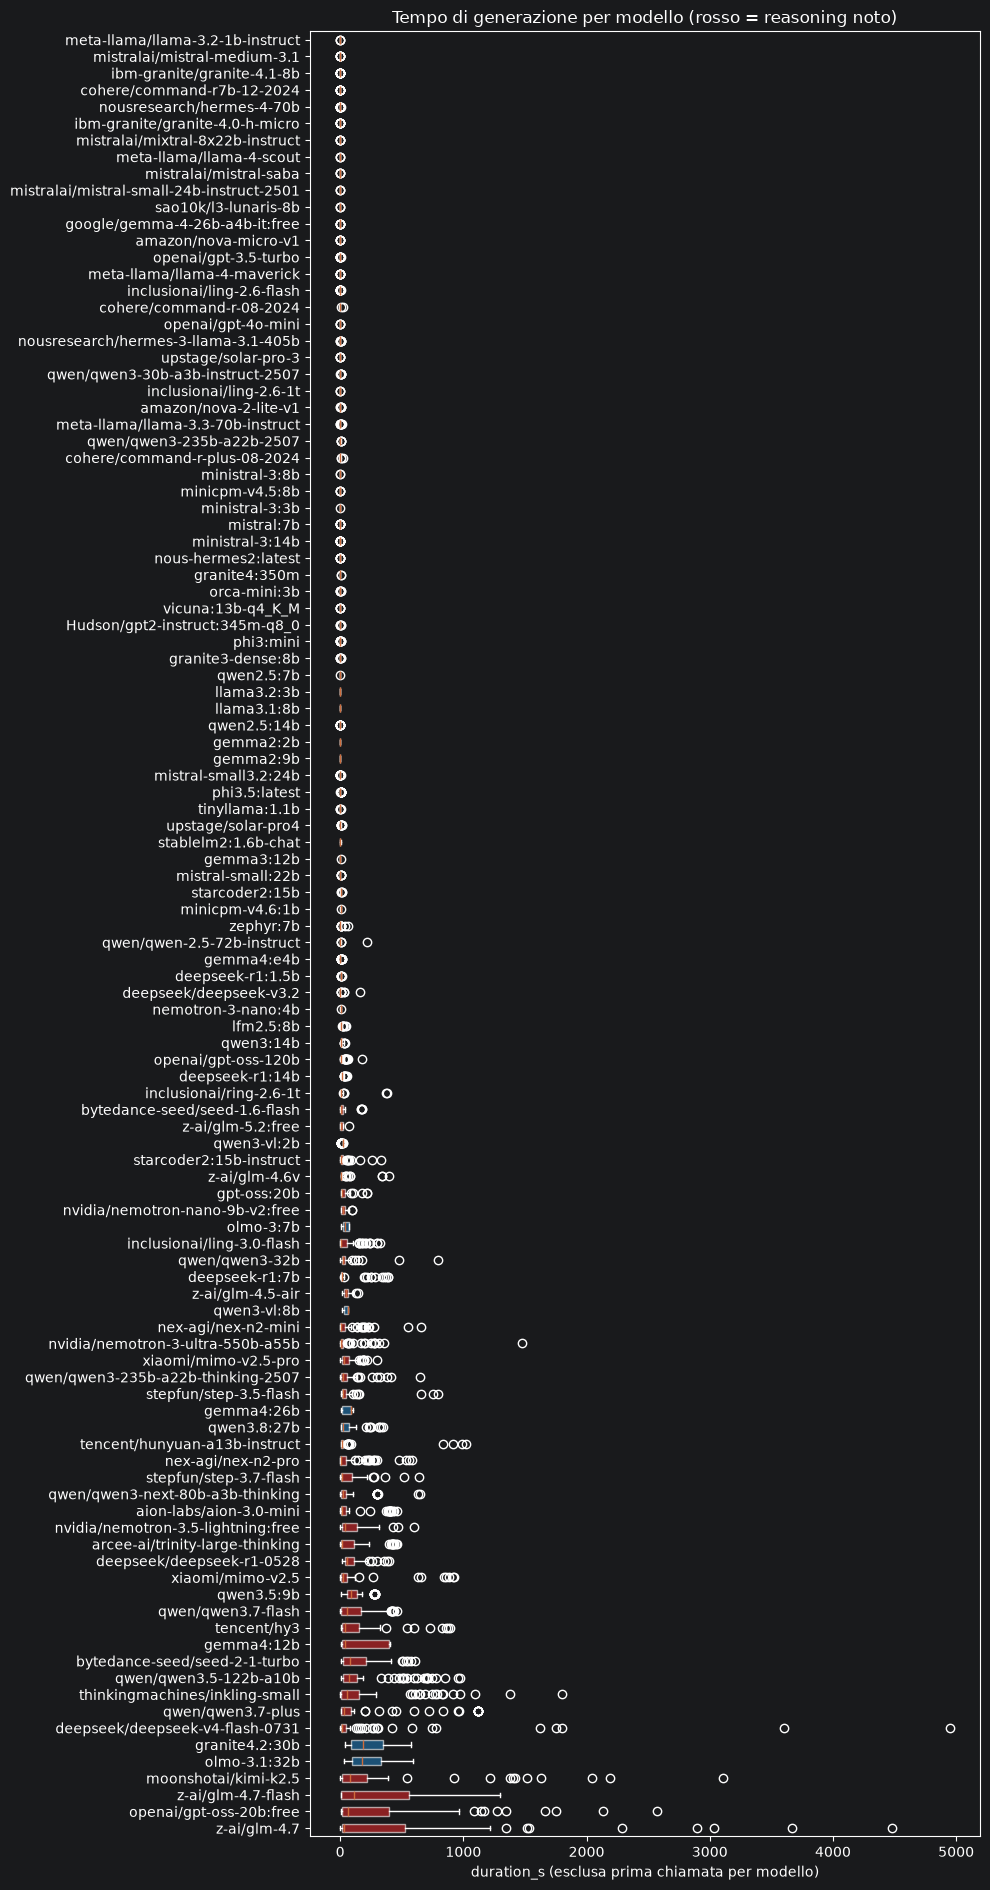

In [137]:
order = timing_data.groupby("model_name")["duration_s"].mean().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 19))
box_data = [timing_data[timing_data["model_name"] == m]["duration_s"].values for m in order]
colors = ["#d62728" if is_reasoning_model(m) else "#1f77b4" for m in order]
bp = ax.boxplot(box_data, orientation="horizontal", tick_labels=list(order), patch_artist=True, showfliers=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_xlabel("duration_s (esclusa prima chiamata per modello)")
ax.set_title("Tempo di generazione per modello (rosso = reasoning noto)")
plt.tight_layout()
plt.show()

## RQ5 — Dimensione del modello vs accuratezza

Solo i modelli locali dichiarano i parametri nel tag (i commerciali no —
per questo RQ5 in senso stretto è verificabile solo qui, come avevamo
già stabilito). I tag senza dimensione riconoscibile vengono segnalati
ed esclusi dal grafico, non stimati a caso.

Modelli senza dimensione ricavabile dal tag (41), esclusi dal grafico:
['z-ai/glm-5.2:free', 'stepfun/step-3.5-flash', 'bytedance-seed/seed-2-1-turbo', 'moonshotai/kimi-k2.5', 'xiaomi/mimo-v2.5-pro', 'qwen/qwen3.7-plus', 'z-ai/glm-4.7', 'deepseek/deepseek-r1-0528', 'deepseek/deepseek-v4-flash-0731', 'nex-agi/nex-n2-pro', 'nex-agi/nex-n2-mini', 'tencent/hy3', 'qwen/qwen3.7-flash', 'xiaomi/mimo-v2.5', 'z-ai/glm-4.6v', 'aion-labs/aion-3.0-mini', 'thinkingmachines/inkling-small', 'stepfun/step-3.7-flash', 'openai/gpt-3.5-turbo', 'cohere/command-r-plus-08-2024', 'inclusionai/ring-2.6-1t', 'nvidia/nemotron-3.5-lightning:free', 'meta-llama/llama-4-maverick', 'bytedance-seed/seed-1.6-flash', 'deepseek/deepseek-v3.2', 'z-ai/glm-4.5-air', 'arcee-ai/trinity-large-thinking', 'inclusionai/ling-2.6-1t', 'mistralai/mistral-medium-3.1', 'upstage/solar-pro4', 'inclusionai/ling-3.0-flash', 'amazon/nova-micro-v1', 'cohere/command-r-08-2024', 'meta-llama/llama-4-scout', 'amazon/nova-2-lite-v1', 'openai/gp

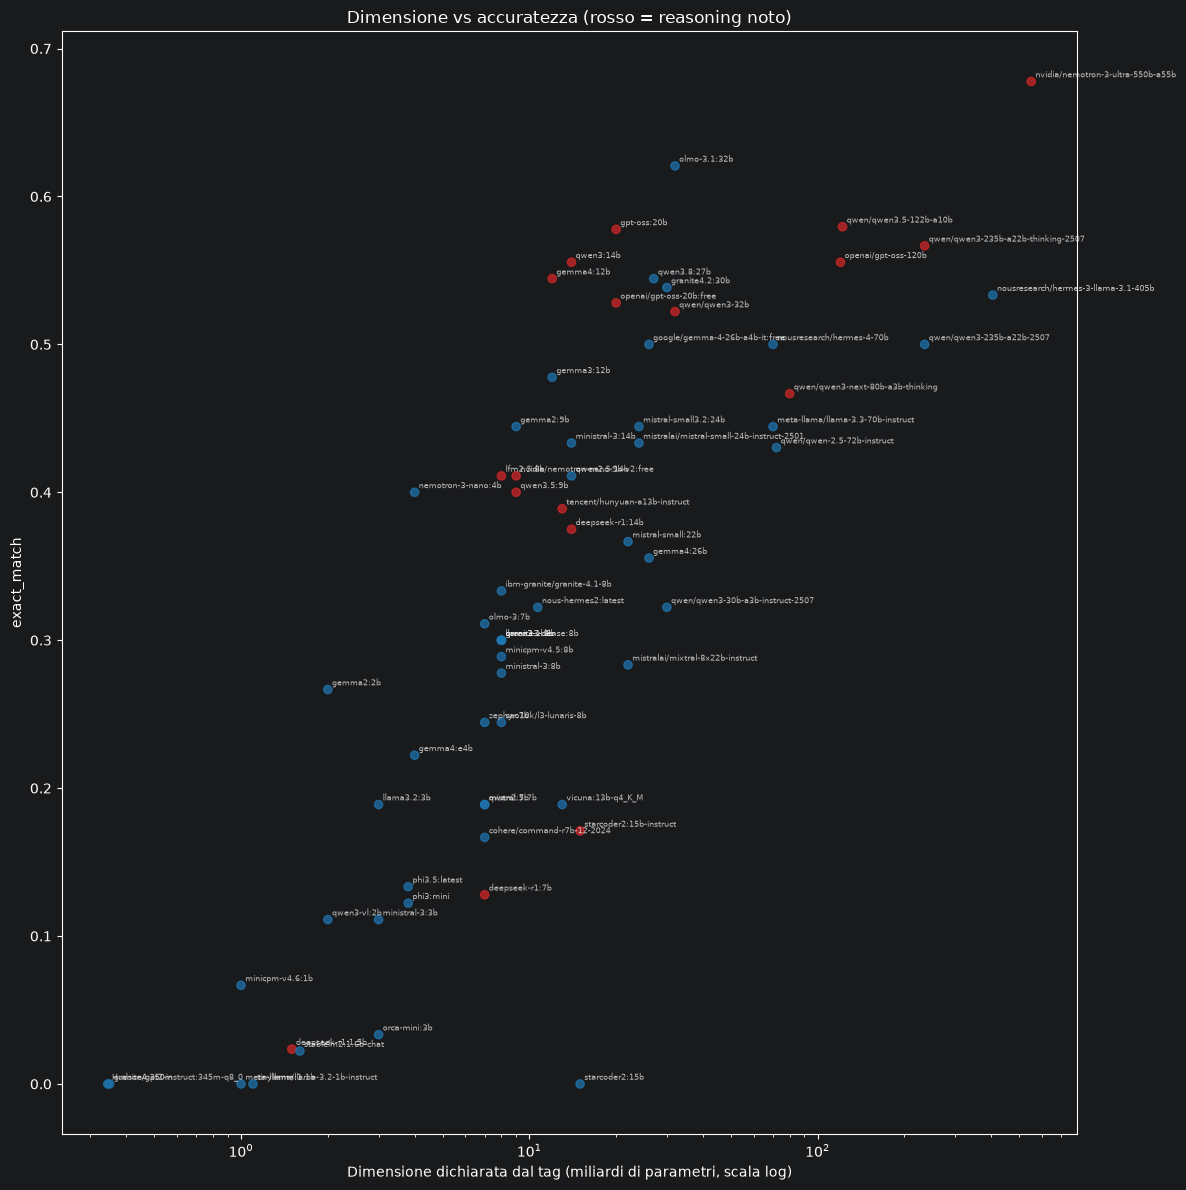

In [138]:
size_df = leaderboard.copy()
size_df["size_b"] = [parse_size_billion(m) for m in size_df.index]

unresolved = size_df[size_df["size_b"].isna()]
if len(unresolved):
    print(f"Modelli senza dimensione ricavabile dal tag ({len(unresolved)}), esclusi dal grafico:")
    print(list(unresolved.index))
    print("Aggiungili a MANUAL_SIZE_OVERRIDES_B se vuoi includerli.\n")

size_df = size_df.dropna(subset=["size_b"])

fig, ax = plt.subplots(figsize=(12, 12))
colors = ["#d62728" if is_reasoning_model(m) else "#1f77b4" for m in size_df.index]
ax.scatter(size_df["size_b"], size_df["exact_match"], c=colors, alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("Dimensione dichiarata dal tag (miliardi di parametri, scala log)")
ax.set_ylabel("exact_match")
ax.set_title("Dimensione vs accuratezza (rosso = reasoning noto)")
for m, row in size_df.iterrows():
    ax.annotate(m, (row["size_b"], row["exact_match"]), fontsize=6, alpha=0.7,
                xytext=(3, 3), textcoords="offset points")
plt.tight_layout()
plt.show()

In [139]:
corr = size_df["size_b"].corr(size_df["exact_match"], method="spearman")
print(f"Correlazione di Spearman dimensione/exact_match (tutti): {corr:.3f}")

corr_non_reasoning = size_df[~size_df.index.map(is_reasoning_model)]
corr2 = corr_non_reasoning["size_b"].corr(corr_non_reasoning["exact_match"], method="spearman")
print(f"Stessa correlazione, solo modelli non-reasoning: {corr2:.3f}")
print("\nSpearman e non Pearson perché non ci interessa la linearità, solo se")
print("dimensione maggiore e ranking di accuratezza tendono a muoversi insieme.")

Correlazione di Spearman dimensione/exact_match (tutti): 0.827
Stessa correlazione, solo modelli non-reasoning: 0.842

Spearman e non Pearson perché non ci interessa la linearità, solo se
dimensione maggiore e ranking di accuratezza tendono a muoversi insieme.


## Clue-echo come indicatore di pavimento di capacità

Quota di risposte identiche (case-insensitive) a una delle 5 clue date —
il modello non ha trovato il connettore, ha ripetuto un indizio in
input. È il segnale più pulito di "questo modello non riesce a fare il
task", più diretto di un semplice `exact_match` basso.

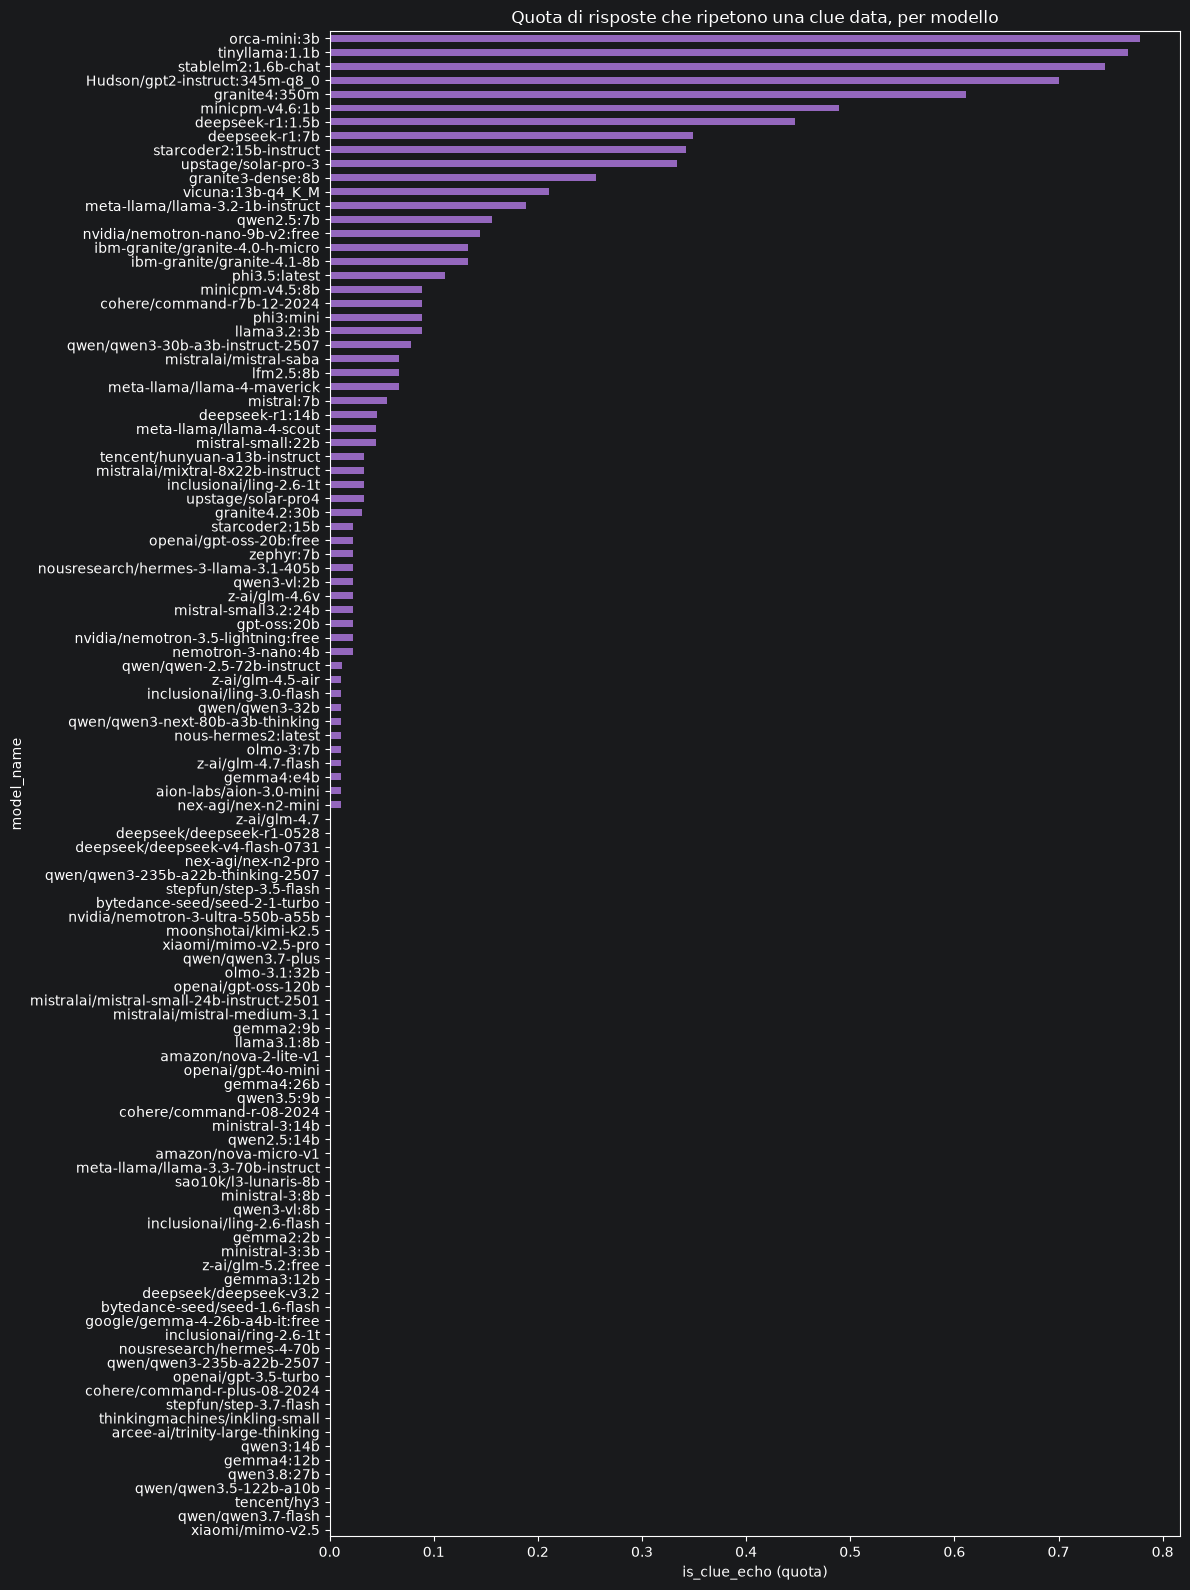

In [140]:
echo_rate = leaderboard["is_clue_echo"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 16))
echo_rate.sort_values().plot.barh(ax=ax, color="#9467bd")
ax.set_xlabel("is_clue_echo (quota)")
ax.set_title("Quota di risposte che ripetono una clue data, per modello")
plt.tight_layout()
plt.show()

## Difficoltà per item

Due controlli distinti: se la fascia di difficoltà che avevi assegnato a
mano è calibrata (accuratezza media che scende da easy a hard — se non
scende, è un segnale che vale la pena rivedere le etichette), e quali
item specifici risultano più duri per *tutti* i modelli insieme (un
item a 0% per tutti è un candidato a essere davvero ambiguo, non solo
difficile).

In [141]:
if "difficulty_note" in ok_data.columns:
    by_difficulty = ok_data.groupby("difficulty_note")["exact_match"].agg(["mean", "count"])
    print("Accuratezza media per fascia di difficoltà dichiarata:")
    print(by_difficulty.round(3))

Accuratezza media per fascia di difficoltà dichiarata:
                  mean  count
difficulty_note              
easy             0.487   1250
hard             0.320   3120
medium           0.407   5010


In [142]:
by_item = ok_data.groupby("prompt_id").agg(
    exact_match=("exact_match", "mean"),
    is_clue_echo=("is_clue_echo", "mean"),
    expected_solution=("expected_solution", "first"),
).sort_values("exact_match")

print("I 10 item più difficili (accuratezza media più bassa tra tutti i modelli):")
by_item.head(30).round(3)

I 10 item più difficili (accuratezza media più bassa tra tutti i modelli):


,exact_match,is_clue_echo,expected_solution
prompt_id,,,
guillo_10,0.000,0.058,pc
guillo_09,0.000,0.084,petrichor
guillo_23,0.000,0.029,concept
guillo_18,0.003,0.058,watching
guillo_29,0.003,0.156,scraping
guillo_21,0.013,0.080,supermarket
guillo_22,0.035,0.177,emotion
guillo_15,0.041,0.060,statistic
guillo_03,0.182,0.064,city


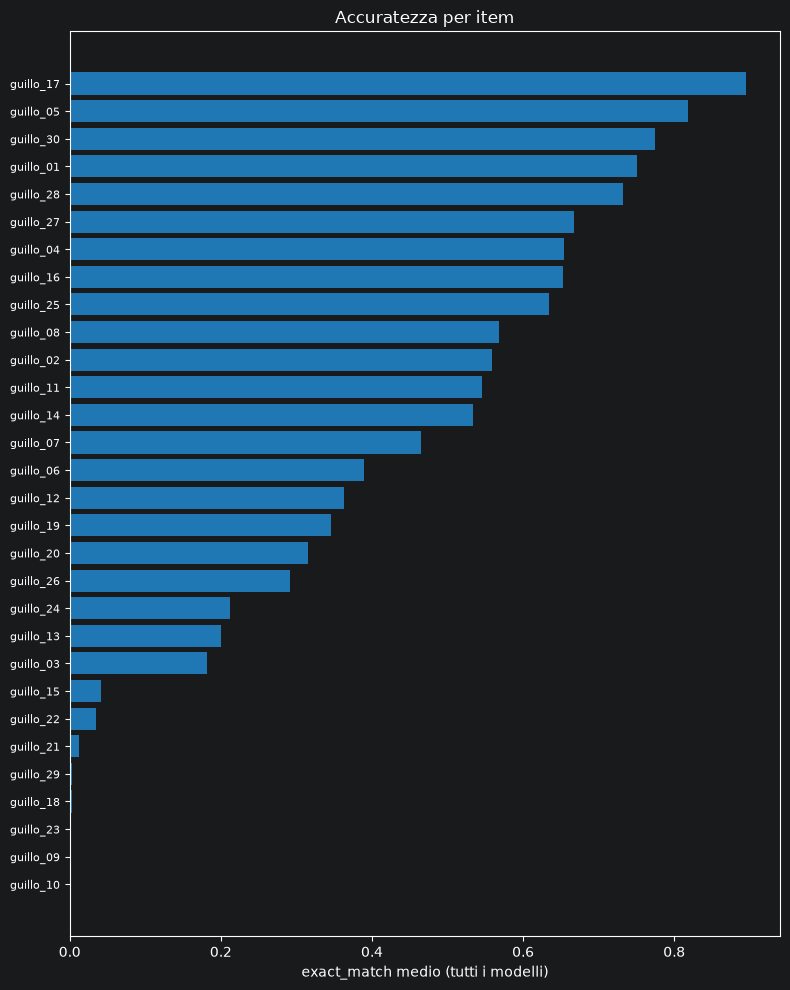

In [143]:
fig, ax = plt.subplots(figsize=(8, 10))
y = np.arange(len(by_item))
ax.barh(y, by_item["exact_match"], color="#1f77b4")
ax.set_yticks(y)
ax.set_yticklabels(by_item.index, fontsize=8)
ax.set_xlabel("exact_match medio (tutti i modelli)")
ax.set_title("Accuratezza per item")
plt.tight_layout()
plt.show()

## Analisi Zipf: la rarità della parola spiega la difficoltà?

Confronta la rarità lessicale (frequenza Zipf, scala logaritmica standard
del pacchetto `wordfreq`: ~1-2 per parole molto rare, ~6-7 per le più
comuni della lingua inglese) della parola-soluzione e delle clue di
ciascun item con l'accuratezza media già calcolata sopra in `by_item` —
per capire se gli item più difficili lo sono perché la parola-soluzione è
rara nella lingua, o per altri motivi (struttura del compito, genericità
della categoria).

Richiede il pacchetto `wordfreq` (`pip install wordfreq`, non incluso
nelle dipendenze base).

In [144]:
# Rarità lessicale (Zipf) di soluzione e clue, per item.
try:
    from wordfreq import zipf_frequency
except ImportError as exc:
    raise ImportError(
        "Manca il pacchetto 'wordfreq': installalo con `pip install wordfreq` "
        "prima di rilanciare questa cella."
    ) from exc

import json as _json
from scipy import stats

PROMPTS_FILE = Path(RESULT_FILES[0]).parent / "guillotine_prompts.json"
with open(PROMPTS_FILE, encoding="utf-8") as f:
    _prompts = {p["prompt_id"]: p for p in _json.load(f)["prompts"]}

zipf_rows = []
for prompt_id, p in _prompts.items():
    clue_zipfs = [zipf_frequency(w, "en") for w in p["clues"]]
    zipf_rows.append({
        "prompt_id": prompt_id,
        "solution": p["solution"],
        "zipf_solution": zipf_frequency(p["solution"], "en"),
        "zipf_clue_min": min(clue_zipfs),
        "zipf_clue_mean": sum(clue_zipfs) / len(clue_zipfs),
    })

zipf_df = pd.DataFrame(zipf_rows).set_index("prompt_id")
zipf_df = zipf_df.join(by_item["exact_match"]).sort_values("zipf_solution")

rho_sol, p_sol = stats.spearmanr(zipf_df["zipf_solution"], zipf_df["exact_match"])
rho_min, p_min = stats.spearmanr(zipf_df["zipf_clue_min"], zipf_df["exact_match"])
rho_mean, p_mean = stats.spearmanr(zipf_df["zipf_clue_mean"], zipf_df["exact_match"])

print(f"Spearman Zipf(soluzione) vs exact_match:   rho={rho_sol:.3f}, p={p_sol:.4f}")
print(f"Spearman Zipf(clue piu' rara) vs exact_match: rho={rho_min:.3f}, p={p_min:.4f}")
print(f"Spearman Zipf(clue media) vs exact_match:   rho={rho_mean:.3f}, p={p_mean:.4f}")

zipf_df.round(3)

Spearman Zipf(soluzione) vs exact_match:   rho=0.241, p=0.1989
Spearman Zipf(clue piu' rara) vs exact_match: rho=0.210, p=0.2665
Spearman Zipf(clue media) vs exact_match:   rho=0.189, p=0.3184


,solution,zipf_solution,zipf_clue_min,zipf_clue_mean,exact_match
prompt_id,,,,,
guillo_09,petrichor,1.60,3.37,4.054,0.000
guillo_14,mandala,2.78,3.31,4.078,0.534
guillo_29,scraping,3.33,3.61,4.416,0.003
guillo_13,surrogate,3.38,2.81,4.600,0.201
guillo_15,statistic,3.45,2.13,4.112,0.041
guillo_27,sustainability,3.77,3.91,4.704,0.668
guillo_11,python,3.78,3.06,3.902,0.546
guillo_21,supermarket,3.78,3.76,4.420,0.013
guillo_06,civilization,4.01,2.93,4.698,0.390


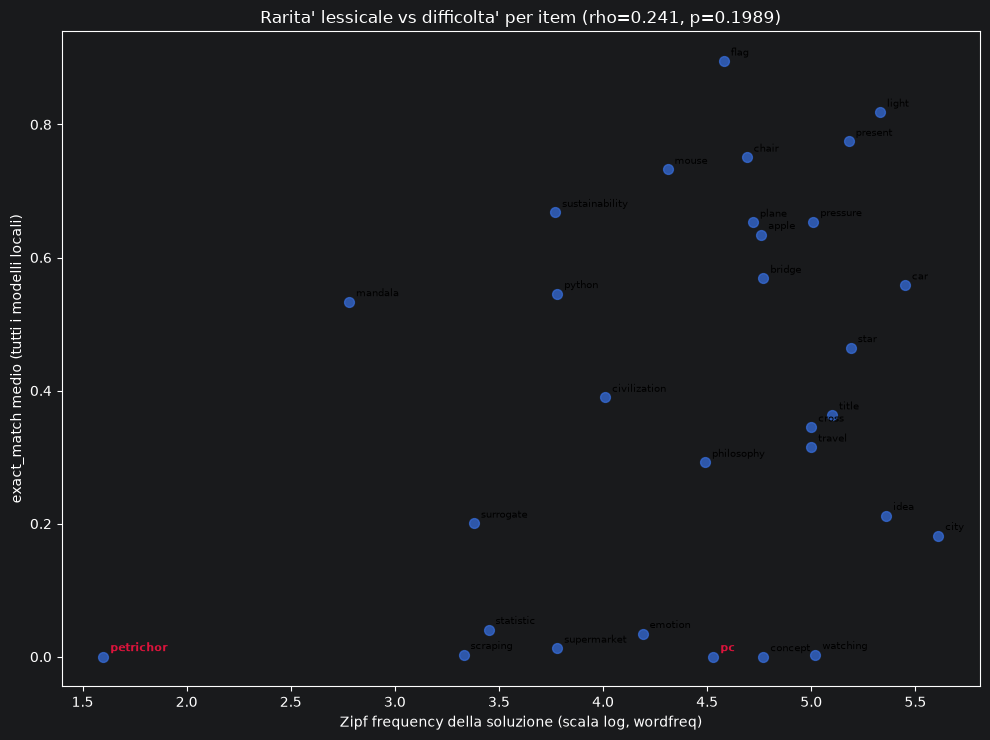

In [145]:
# Scatter Zipf(soluzione) vs exact_match, 30 item etichettati -
# evidenzia petrichor e pc, i due outlier agli estremi opposti
# (parola piu' rara del dataset ma difficolta' "attesa"; parola comune
# ma difficolta' strutturale, non lessicale).
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.scatter(zipf_df["zipf_solution"], zipf_df["exact_match"], alpha=0.75, s=50)

for prompt_id, row in zipf_df.iterrows():
    is_outlier = prompt_id in ("guillo_09", "guillo_10")
    ax.annotate(
        row["solution"],
        (row["zipf_solution"], row["exact_match"]),
        fontsize=8 if is_outlier else 7,
        color="crimson" if is_outlier else "black",
        fontweight="bold" if is_outlier else "normal",
        xytext=(5, 4), textcoords="offset points",
    )

ax.set_xlabel("Zipf frequency della soluzione (scala log, wordfreq)")
ax.set_ylabel("exact_match medio (tutti i modelli locali)")
ax.set_title(f"Rarita' lessicale vs difficolta' per item (rho={rho_sol:.3f}, p={p_sol:.4f})")
plt.tight_layout()
plt.show()

## Esportazione tabelle riassuntive

Salva le tabelle principali come CSV, pronte per essere riprese nel
whitepaper senza dover ricopiare numeri a mano dal notebook.

In [146]:
OUTPUT_DIR = Path(RESULT_FILES[0]).parent
leaderboard.round(4).to_csv(OUTPUT_DIR / "analisi_leaderboard.csv")
temp_pivot.round(4).to_csv(OUTPUT_DIR / "analisi_temperatura.csv")
by_item.round(4).to_csv(OUTPUT_DIR / "analisi_per_item.csv")

print(f"Tabelle esportate in {OUTPUT_DIR}")

Tabelle esportate in D:\guillotine\guillotine\source


---
# Estensioni: frequenza risposte, test statistico su T, tempo/difficoltà, same_root

## Frequenza delle risposte per item

Per un dato `prompt_id`, la distribuzione di tutte le risposte date da
tutti i modelli/temperature — utile per vedere non solo *se* un item è
difficile ma *come* i modelli sbagliano: convergono su un sinonimo
valido, su una clue ripetuta, o si disperdono in modo casuale?

In [147]:
def response_frequency(prompt_id, data=ok_data, top=10):
    subset = data[data["prompt_id"] == prompt_id].copy()
    subset["predicted_norm"] = subset["predicted_word"].astype(str).str.strip().str.lower()
    counts = subset["predicted_norm"].value_counts().head(top)
    expected = subset["expected_solution"].iloc[0] if len(subset) else "?"
    print(f"{prompt_id} (atteso: {expected!r}), {len(subset)} risposte totali:")
    return counts

# esempio: cambia il prompt_id per guardare un item diverso, es. "guillo_10" per PC
response_frequency("guillo_02")

guillo_02 (atteso: 'car'), 315 risposte totali:


predicted_norm
car           175
vehicle        35
road           15
auto           14
insurance      10
motor           7
automobile      6
transport       6
truck           4
cover           3
Name: count, dtype: int64

guillo_02 (atteso: 'car'), 315 risposte totali:


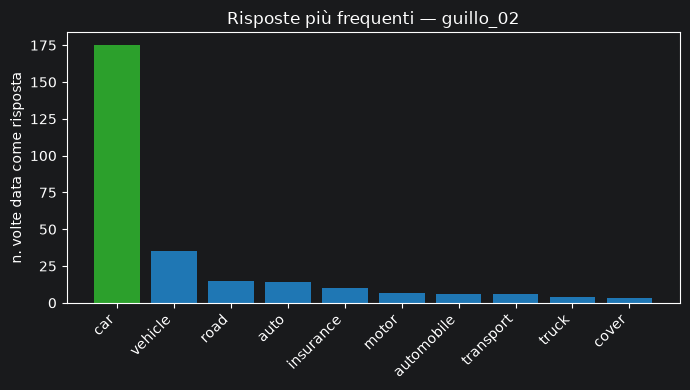

In [148]:
def plot_response_frequency(prompt_id, data=ok_data, top=10):
    counts = response_frequency(prompt_id, data, top)
    expected = data[data["prompt_id"] == prompt_id]["expected_solution"].iloc[0].lower()
    colors = ["#2ca02c" if w == expected else "#1f77b4" for w in counts.index]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_ylabel("n. volte data come risposta")
    ax.set_title(f"Risposte più frequenti — {prompt_id}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# esempio, cambia il prompt_id per guardare un item diverso
plot_response_frequency("guillo_02")

## Temperatura: Cochran's Q, non chi-quadro

Un chi-quadro di indipendenza tratterebbe ogni cella come un campione
indipendente — ma qui non lo è: gli stessi 30 item vengono ripresentati
allo stesso modello a T=0.0, 0.3 e 0.7. È un disegno a misure ripetute
(stesso "soggetto", 3 condizioni), non campioni indipendenti. Il test
corretto per confrontare proporzioni binarie (corretto/sbagliato) su 3+
condizioni appaiate è **Cochran's Q** (generalizzazione di McNemar a più
di 2 condizioni), non il chi-quadro.

Richiede che l'item sia presente in tutte e 3 le temperature — i timeout
riducono il campione utilizzabile, e questo va dichiarato, non nascosto.

In [149]:
from statsmodels.stats.contingency_tables import cochrans_q

def temperature_cochran_q(model_name, data=ok_data):
    sub = data[data["model_name"] == model_name]
    pivot = sub.pivot_table(index="prompt_id", columns="temperature", values="exact_match")
    pivot_complete = pivot.dropna()

    print(f"{model_name}: item con tutte e 3 le T presenti: {len(pivot_complete)}/{len(pivot)}")
    if len(pivot_complete) < 10:
        print("Meno di 10 item completi - risultato da interpretare con cautela.")
    if len(pivot_complete) < 5:
        print("Troppo pochi per un test affidabile, salto.")
        return None

    result = cochrans_q(pivot_complete.values)
    print(f"Cochran's Q = {result.statistic:.3f}, p-value = {result.pvalue:.4f}")
    return result

# esempio su un modello reasoning, dove la sensibilita' alla temperatura
# e' piu' plausibile a priori
temperature_cochran_q("deepseek-r1:7b")

deepseek-r1:7b: item con tutte e 3 le T presenti: 26/30
Cochran's Q = 6.333, p-value = 0.0421


<bunch containing results, print to see contents>

In [150]:
# Applicato a tutti i modelli con abbastanza item completi
q_results = []
skipped_no_variance = []

for m in ok_data["model_name"].unique():
    sub = ok_data[ok_data["model_name"] == m]
    pivot = sub.pivot_table(index="prompt_id", columns="temperature", values="exact_match").dropna()
    if len(pivot) < 10:
        continue

    # Cochran's Q e' indefinito (0/0) se nessun item cambia esito tra le
    # temperature - il modello risponde in modo identico (giusto o sbagliato)
    # su ogni item a ogni T. Non e' un errore, e' che non c'e' niente da
    # testare: si salta con una nota invece di lasciare che statsmodels
    # produca NaN con un RuntimeWarning silenzioso.
    n_varying_items = (pivot.min(axis=1) != pivot.max(axis=1)).sum()
    if n_varying_items == 0:
        skipped_no_variance.append(m)
        continue

    r = cochrans_q(pivot.values)
    q_results.append({
        "model_name": m, "n_item_completi": len(pivot),
        "n_item_variabili": n_varying_items, "Q": r.statistic, "p_value": r.pvalue,
    })

q_df = pd.DataFrame(q_results).sort_values("p_value")
print(f"Modelli saltati (nessun item cambia esito tra T, test non definito): {len(skipped_no_variance)}")
if skipped_no_variance:
    print(skipped_no_variance)

print(f"\nModelli con p < 0.05 (accuratezza dipende dalla temperatura, con questo N):")
q_df[q_df["p_value"] < 0.05].round(4)

Modelli saltati (nessun item cambia esito tra T, test non definito): 12
['granite4:350m', 'Hudson/gpt2-instruct:345m-q8_0', 'ibm-granite/granite-4.1-8b', 'inclusionai/ling-2.6-flash', 'meta-llama/llama-3.2-1b-instruct', 'meta-llama/llama-4-maverick', 'nousresearch/hermes-3-llama-3.1-405b', 'openai/gpt-3.5-turbo', 'orca-mini:3b', 'starcoder2:15b', 'tinyllama:1.1b', 'mistralai/mistral-medium-3.1']

Modelli con p < 0.05 (accuratezza dipende dalla temperatura, con questo N):


,model_name,n_item_completi,n_item_variabili,Q,p_value
19,gemma4:26b,30,10,12.2000,0.0022
18,gemma4:12b,30,5,7.6000,0.0224
47,nousresearch/hermes-4-70b,30,6,7.0000,0.0302
20,gemma4:e4b,30,9,6.8889,0.0319
14,deepseek-r1:7b,26,6,6.3333,0.0421
79,tencent/hunyuan-a13b-instruct,30,9,6.2222,0.0446
76,starcoder2:15b-instruct,19,3,6.0000,0.0498
35,ministral-3:14b,30,3,6.0000,0.0498
81,thinkingmachines/inkling-small,30,4,6.0000,0.0498


## Tempo di generazione come proxy di difficoltà — solo modelli reasoning

Coerente con quanto discusso: la variabilità del tempo ha senso come
proxy di "quanto il modello ha dovuto pensare" solo per i modelli
reasoning (compute variabile per token). Qui lo testiamo davvero invece
di argomentarlo solo qualitativamente: tempo medio per item vs
accuratezza per item, e tempo medio per fascia di difficoltà dichiarata.

In [151]:
reasoning_data = ok_data[
    ok_data["is_reasoning_model"] & (ok_data["is_first_call"] != 1) & ok_data["duration_s"].notna()
]

by_item_timing = reasoning_data.groupby("prompt_id").agg(
    duration_mean=("duration_s", "mean"),
    exact_match=("exact_match", "mean"),
    difficulty_note=("difficulty_note", "first"),
).sort_values("duration_mean", ascending=False)

corr_time_acc = by_item_timing["duration_mean"].corr(by_item_timing["exact_match"], method="spearman")
print(f"Correlazione Spearman tempo medio/accuratezza per item (modelli reasoning): {corr_time_acc:.3f}")
print("(negativa e forte = item piu' lenti da generare tendono ad avere accuratezza piu' bassa,")
print(" coerente con \"tempo come proxy di difficolta'\" per questa classe di modelli)")

by_item_timing.head(30).round(2)

Correlazione Spearman tempo medio/accuratezza per item (modelli reasoning): -0.672
(negativa e forte = item piu' lenti da generare tendono ad avere accuratezza piu' bassa,
 coerente con "tempo come proxy di difficolta'" per questa classe di modelli)


,duration_mean,exact_match,difficulty_note
prompt_id,,,
guillo_09,295.05,0.00,hard
guillo_29,260.93,0.01,hard
guillo_03,229.14,0.20,medium
guillo_24,191.06,0.26,hard
guillo_23,186.66,0.00,hard
guillo_11,162.47,0.69,medium
guillo_20,156.20,0.36,medium
guillo_22,146.48,0.00,medium
guillo_26,127.04,0.50,medium


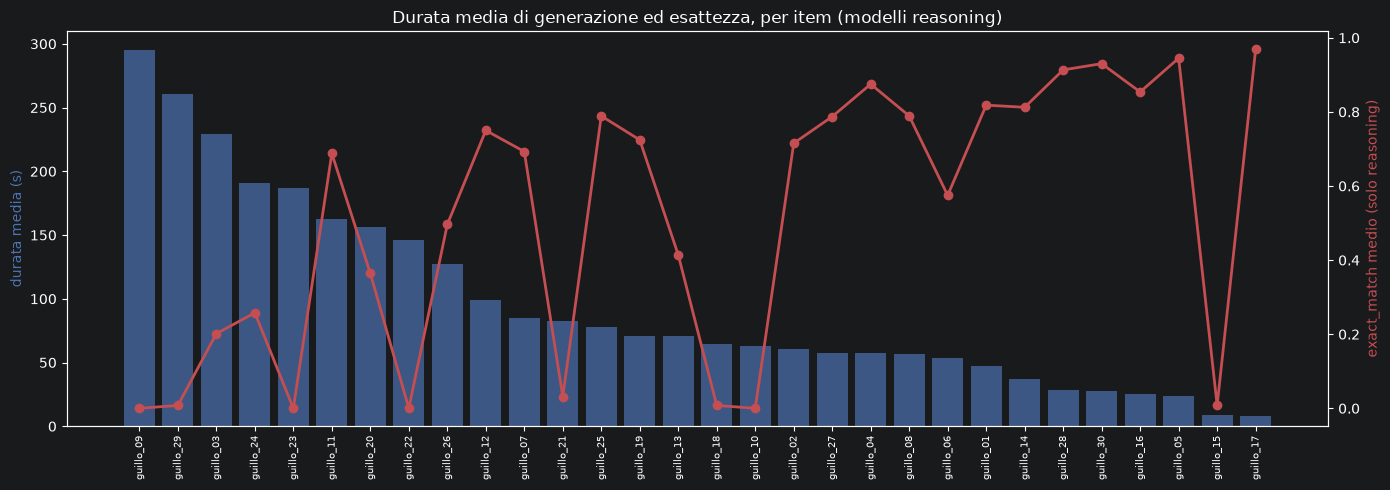

In [152]:
fig, ax1 = plt.subplots(figsize=(14, 5))
x = np.arange(len(by_item_timing))
ax1.bar(x, by_item_timing["duration_mean"], color="#4c72b0", alpha=0.7)
ax1.set_ylabel("durata media (s)", color="#4c72b0")
ax1.set_xticks(x)
ax1.set_xticklabels(by_item_timing.index, rotation=90, fontsize=7)

ax2 = ax1.twinx()
ax2.plot(x, by_item_timing["exact_match"], color="#c44e52", marker="o", linewidth=2)
ax2.set_ylabel("exact_match medio (solo reasoning)", color="#c44e52")

ax1.set_title("Durata media di generazione ed esattezza, per item (modelli reasoning)")
fig.tight_layout()
plt.show()

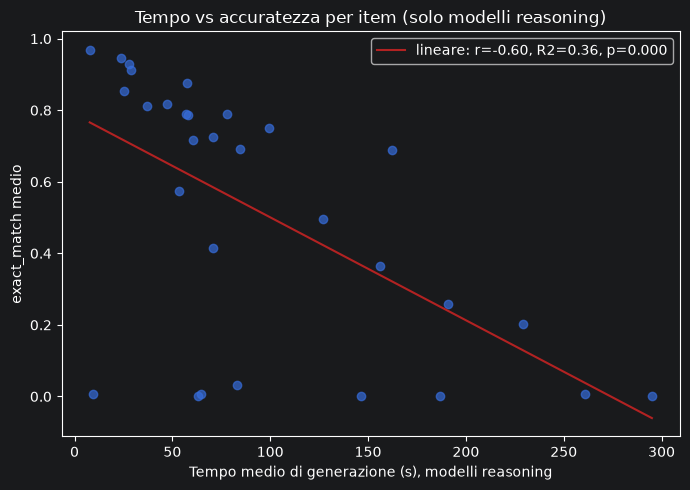

Spearman rho = -0.672 (p=0.0000) - riportata piu' sopra, e' la misura primaria:
cattura la relazione monotona senza assumere linearita', robusta al punto in alto a sinistra
che nella dispersione si vede chiaramente essere un potenziale outlier.

Tempo per fascia di difficolta' dichiarata (modelli reasoning):


,mean,std,count
difficulty_note,,,
easy,62.4,159.8,506
hard,124.8,308.5,1277
medium,85.1,250.0,2047


In [153]:
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 5))
x, y = by_item_timing["duration_mean"].values, by_item_timing["exact_match"].values

ax.scatter(x, y, alpha=0.7)

# Retta di regressione lineare (grado 1) - vedi cella sotto per il perche'
# non si va oltre: con questo N, gradi piu' alti peggiorano la capacita'
# predittiva anche se l'R2 dentro-campione sembra migliore.
lin = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 50)
ax.plot(x_line, lin.intercept + lin.slope * x_line, color="firebrick",
        label=f"lineare: r={lin.rvalue:.2f}, R2={lin.rvalue**2:.2f}, p={lin.pvalue:.3f}")
ax.legend()

ax.set_xlabel("Tempo medio di generazione (s), modelli reasoning")
ax.set_ylabel("exact_match medio")
ax.set_title("Tempo vs accuratezza per item (solo modelli reasoning)")
plt.tight_layout()
plt.show()

rho, p_rho = stats.spearmanr(x, y)
print(f"Spearman rho = {rho:.3f} (p={p_rho:.4f}) - riportata piu' sopra, e' la misura primaria:")
print("cattura la relazione monotona senza assumere linearita', robusta al punto in alto a sinistra")
print("che nella dispersione si vede chiaramente essere un potenziale outlier.")

by_diff_timing = reasoning_data.groupby("difficulty_note")["duration_s"].agg(["mean", "std", "count"])
print("\nTempo per fascia di difficolta' dichiarata (modelli reasoning):")
by_diff_timing.round(1)

## `same_root`: quanto aggiunge sopra `exact_match`

`same_root` è sempre un sovrainsieme di `exact_match` (verificato: zero
righe con `exact_match=1` e `same_root=0` — logico, dato che la stessa
parola ha sempre la stessa radice di se stessa). Quindi nella
classifica, `same_root=0.785` **non** significa "78.5% aggiuntivo", vuol
dire "78.5% totale, di cui una parte è già negli exact match". La
colonna sotto isola solo l'incremento vero (`same_root` ma non
`exact_match` — plurali, coniugazioni, variazioni morfologiche non
esatte).

In [154]:
violation_mask = (ok_data["exact_match"] == 1) & (ok_data["same_root"] == 0)
n_violations = violation_mask.sum()

if n_violations:
    print(f"ATTENZIONE: {n_violations} righe con exact_match=1 ma same_root=0 (atteso: 0).")
    print("Probabile causa: predicted_word corretto a mano senza rilanciare rescore.py dopo.")
    print("Righe coinvolte, per modello:")
    print(ok_data.loc[violation_mask, "model_name"].value_counts())
else:
    print("Nessuna violazione: same_root e' sempre un sovrainsieme di exact_match, come atteso.")

ok_data["same_root_only"] = ((ok_data["same_root"] == 1) & (ok_data["exact_match"] == 0)).astype(int)

breakdown = ok_data.groupby("model_name").agg(
    exact_match=("exact_match", "mean"),
    same_root_only=("same_root_only", "mean"),
).sort_values("exact_match", ascending=False)
breakdown["same_root_totale"] = breakdown["exact_match"] + breakdown["same_root_only"]

breakdown.round(3)

ATTENZIONE: 3 righe con exact_match=1 ma same_root=0 (atteso: 0).
Probabile causa: predicted_word corretto a mano senza rilanciare rescore.py dopo.
Righe coinvolte, per modello:
model_name
deepseek-r1:7b             1
qwen2.5:14b                1
starcoder2:15b-instruct    1
Name: count, dtype: int64


,exact_match,same_root_only,same_root_totale
model_name,,,
z-ai/glm-5.2:free,0.750,0.000,0.750
stepfun/step-3.5-flash,0.711,0.067,0.778
bytedance-seed/seed-2-1-turbo,0.678,0.067,0.744
nvidia/nemotron-3-ultra-550b-a55b,0.678,0.067,0.744
moonshotai/kimi-k2.5,0.663,0.067,0.730
...,...,...,...
Hudson/gpt2-instruct:345m-q8_0,0.000,0.022,0.022
meta-llama/llama-3.2-1b-instruct,0.000,0.000,0.000
granite4:350m,0.000,0.000,0.000


---
# Quadro statistico completo

Richiede `synonym_manual`/`coherence_manual` compilate (lo sono, 100%) per
avere senso pieno - alcune sezioni sotto sarebbero poco informative a
revisione parziale.

## Intervalli di confidenza sulla classifica (Wilson score)

Ogni tasso di accuratezza è una proporzione su ~90 prove (30 item × 3
temperature, meno i timeout) — un punto stimato senza intervallo nasconde
quanto è incerto. Wilson invece di Wald/normale perché è più affidabile
con proporzioni vicine a 0 o 1 e campioni non enormi, esattamente il
nostro caso.

In [155]:
from statsmodels.stats.proportion import proportion_confint

leaderboard_ci = ok_data.groupby("model_name").agg(
    n=("exact_match", "size"), exact_match=("exact_match", "mean"),
).sort_values("exact_match", ascending=False)

successes = (leaderboard_ci["exact_match"] * leaderboard_ci["n"]).round().astype(int)
leaderboard_ci["ci_low"], leaderboard_ci["ci_high"] = proportion_confint(
    successes, leaderboard_ci["n"], method="wilson"
)
leaderboard_ci.round(3)

,n,exact_match,ci_low,ci_high
model_name,,,,
z-ai/glm-5.2:free,4,0.750,0.301,0.954
stepfun/step-3.5-flash,90,0.711,0.610,0.795
bytedance-seed/seed-2-1-turbo,90,0.678,0.576,0.765
nvidia/nemotron-3-ultra-550b-a55b,90,0.678,0.576,0.765
moonshotai/kimi-k2.5,89,0.663,0.560,0.753
...,...,...,...,...
Hudson/gpt2-instruct:345m-q8_0,90,0.000,0.000,0.041
meta-llama/llama-3.2-1b-instruct,90,0.000,0.000,0.041
granite4:350m,90,0.000,0.000,0.041


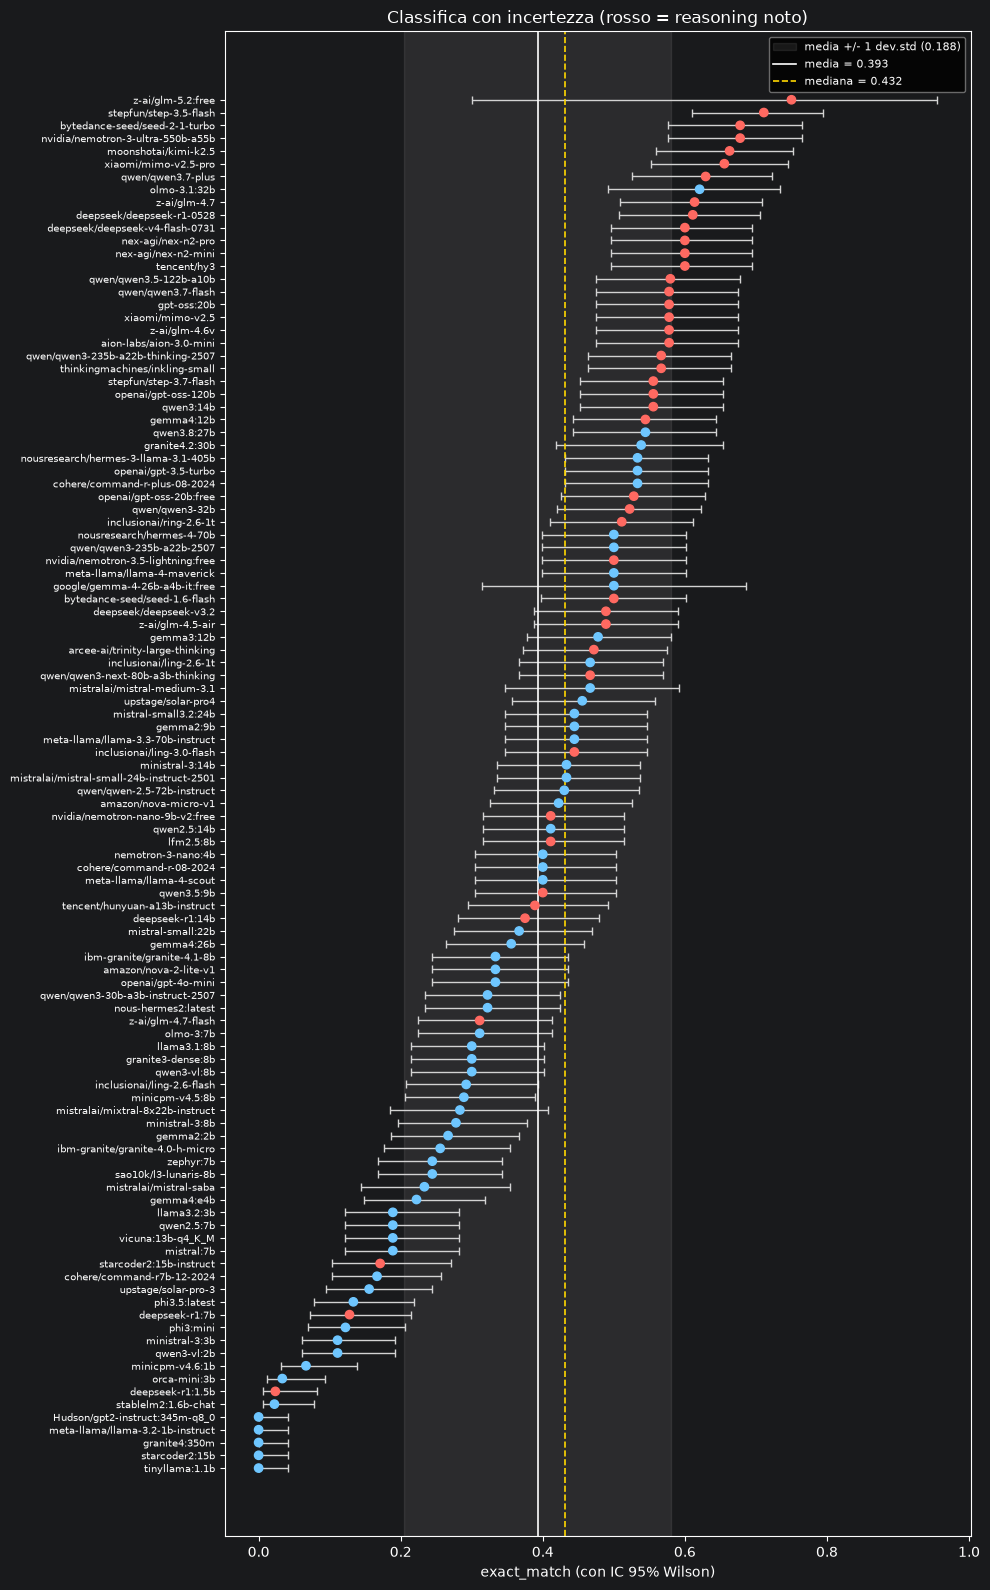

In [156]:
fig, ax = plt.subplots(figsize=(10, 16))
y = np.arange(len(leaderboard_ci))
colors = ["#ff6961" if is_reasoning_model(m) else "#6ec6ff" for m in leaderboard_ci.index]

ax.errorbar(
    leaderboard_ci["exact_match"], y,
    xerr=[leaderboard_ci["exact_match"] - leaderboard_ci["ci_low"],
          leaderboard_ci["ci_high"] - leaderboard_ci["exact_match"]],
    fmt="none", ecolor="lightgray", elinewidth=1, capsize=3, zorder=2,
)
ax.scatter(leaderboard_ci["exact_match"], y, color=colors, zorder=3)

mean_val = leaderboard_ci["exact_match"].mean()
median_val = leaderboard_ci["exact_match"].median()
std_val = leaderboard_ci["exact_match"].std()

ax.axvspan(mean_val - std_val, mean_val + std_val, color="white", alpha=0.08,
           label=f"media +/- 1 dev.std ({std_val:.3f})")
ax.axvline(mean_val, color="white", linestyle="-", linewidth=1.2,
           label=f"media = {mean_val:.3f}")
ax.axvline(median_val, color="gold", linestyle="--", linewidth=1.2,
           label=f"mediana = {median_val:.3f}")
ax.legend(fontsize=8, facecolor="black", edgecolor="gray", labelcolor="white")

ax.set_yticks(y)
ax.set_yticklabels(leaderboard_ci.index, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("exact_match (con IC 95% Wilson)")
ax.set_title("Classifica con incertezza (rosso = reasoning noto)")
plt.tight_layout()
plt.show()

## Correttezza estesa: exact / +same_root / +synonym_manual

Ora che `synonym_manual` è completa al 100%, questa è probabilmente la
metrica più onesta per RQ1 — non solo match esatto, ma tutto ciò che tu
hai giudicato una risposta valida, scomposto per capire da dove viene
ciascun incremento.

In [157]:
ok_data["same_root_only"] = ((ok_data["same_root"] == 1) & (ok_data["exact_match"] == 0)).astype(int)
ok_data["synonym_only"] = (
    (ok_data["synonym_manual"] == 1) & (ok_data["exact_match"] == 0) & (ok_data["same_root"] == 0)
).astype(int)
ok_data["broad_correct"] = (
    (ok_data["exact_match"] == 1) | (ok_data["same_root"] == 1) | (ok_data["synonym_manual"] == 1)
).astype(int)

extended = ok_data.groupby("model_name").agg(
    exact_match=("exact_match", "mean"),
    same_root_only=("same_root_only", "mean"),
    synonym_only=("synonym_only", "mean"),
    broad_correct=("broad_correct", "mean"),
).sort_values("broad_correct", ascending=False)

extended.round(3)

,exact_match,same_root_only,synonym_only,broad_correct
model_name,,,,
bytedance-seed/seed-2-1-turbo,0.678,0.067,0.056,0.800
nvidia/nemotron-3-ultra-550b-a55b,0.678,0.067,0.044,0.789
stepfun/step-3.5-flash,0.711,0.067,0.011,0.789
moonshotai/kimi-k2.5,0.663,0.067,0.034,0.764
xiaomi/mimo-v2.5-pro,0.656,0.067,0.033,0.756
...,...,...,...,...
stablelm2:1.6b-chat,0.022,0.000,0.011,0.033
meta-llama/llama-3.2-1b-instruct,0.000,0.000,0.000,0.000
granite4:350m,0.000,0.000,0.000,0.000


## Accordo automatico/manuale (Cohen's Kappa)

Quanto le metriche automatiche (`same_root` o `is_similar_lev`) catturano
già da sole quello che tu hai giudicato un sinonimo valido, tra le
risposte non-esatte? Se l'accordo è basso, la revisione manuale non era
un di più prudenziale, era necessaria — questo lo quantifica invece di
darlo per scontato.

In [158]:
from statsmodels.stats.inter_rater import cohens_kappa

not_exact = ok_data[ok_data["exact_match"] == 0].copy()
n_before = len(not_exact)
not_exact = not_exact[not_exact["synonym_manual"].notna()].copy()
n_missing_review = n_before - len(not_exact)
if n_missing_review:
    print(f"{n_missing_review} righe non-esatte senza synonym_manual compilato, escluse da questo confronto.")

if len(not_exact) < 10:
    print(f"Solo {len(not_exact)} righe con synonym_manual compilato tra le non-esatte - "
          f"troppo poche per un Kappa affidabile. Rilancia questa cella a revisione piu' avanzata.")
else:
    not_exact["auto_flag"] = ((not_exact["same_root"] == 1) | (not_exact["is_similar_lev"] == 1)).astype(int)
    not_exact["manual_flag"] = not_exact["synonym_manual"].astype(int)

    table = pd.crosstab(not_exact["auto_flag"], not_exact["manual_flag"])
    print("Automatico (righe) vs sinonimo manuale (colonne), tra le non-esatte:")
    print(table)

    kappa_result = cohens_kappa(table.values)
    agreement_pct = (not_exact["auto_flag"] == not_exact["manual_flag"]).mean()
    missed = ((not_exact["auto_flag"] == 0) & (not_exact["manual_flag"] == 1)).sum()

    print(f"\nCohen's Kappa: {kappa_result.kappa:.3f}")
    print(f"Accordo grezzo: {agreement_pct:.1%}")
    print(f"Sinonimi validi che l'automatico da solo NON avrebbe preso: {missed} righe")

Automatico (righe) vs sinonimo manuale (colonne), tra le non-esatte:
manual_flag     0    1
auto_flag             
0            4662  468
1             570   32

Cohen's Kappa: -0.041
Accordo grezzo: 81.9%
Sinonimi validi che l'automatico da solo NON avrebbe preso: 468 righe


## Indice di discriminazione degli item (Classical Test Theory)

Preso in prestito dalla psicometria: per ogni item, correlazione
punto-biseriale tra "il modello lo risolve" e "il punteggio totale del
modello sugli *altri* 29 item" (corretto per evitare l'inflazione
parte-tutto). Un item con discriminazione alta separa bene i modelli
forti dai deboli — uno con discriminazione bassa o negativa non traccia
la capacità generale, probabilmente per un problema nell'item stesso,
non nei modelli.

Item dove *tutti* i modelli concordano (0% o 100% per tutti) non sono
testabili: nessuna varianza da correlare, non un errore.

In [159]:
from scipy.stats import pointbiserialr

item_model_matrix = ok_data.pivot_table(index="model_name", columns="prompt_id", values="exact_match", aggfunc="mean")

discrimination, difficulty_p, skipped_constant = {}, {}, []
for item in item_model_matrix.columns:
    item_scores = item_model_matrix[item]
    total_minus_item = item_model_matrix.drop(columns=[item]).mean(axis=1)
    valid = item_scores.notna() & total_minus_item.notna()
    if valid.sum() < 5:
        continue
    difficulty_p[item] = item_scores.mean()
    if item_scores[valid].nunique() < 2:
        skipped_constant.append(item)
        continue
    r, _ = pointbiserialr(item_scores[valid], total_minus_item[valid])
    discrimination[item] = r

disc_df = pd.DataFrame({"difficolta_p": pd.Series(difficulty_p), "discriminazione": pd.Series(discrimination)})
disc_df_ranked = disc_df.dropna(subset=["discriminazione"]).sort_values("discriminazione")

print(f"Item non testabili (nessuna varianza tra modelli): {skipped_constant}")
print("\nItem con discriminazione piu\' bassa (candidati a revisione, come guillo_08/19/25 in precedenza):")
disc_df_ranked.head(8).round(3)

Item non testabili (nessuna varianza tra modelli): ['guillo_09', 'guillo_10', 'guillo_23']

Item con discriminazione piu' bassa (candidati a revisione, come guillo_08/19/25 in precedenza):


,difficolta_p,discriminazione
guillo_15,0.040,-0.161
guillo_18,0.003,-0.146
guillo_22,0.034,-0.094
guillo_03,0.184,0.069
guillo_21,0.012,0.122
guillo_29,0.003,0.142
guillo_24,0.212,0.263
guillo_20,0.314,0.293


## Stabilità del ranking tra temperature

Non è "cross-validation" in senso stretto — quella è una tecnica per
validare un modello predittivo, qui non ne stiamo addestrando uno.
L'equivalente corretto della tua domanda ("i calcoli sono coerenti tra le
temperature?") è controllare se il **ranking dei modelli per accuratezza**
resta stabile a T diverse: se sì, la temperatura sposta l'accuratezza
assoluta di qualche punto ma non ribalta chi è meglio di chi (segnale di
misurazione affidabile); se il ranking cambiasse molto, sarebbe un
problema serio, o del disegno o della metrica.

In [160]:
from scipy.stats import spearmanr

rank_by_temp = ok_data.pivot_table(index="model_name", columns="temperature", values="exact_match", aggfunc="mean")

temps = rank_by_temp.columns.tolist()
print("Correlazione di Spearman tra i ranking dei modelli a coppie di temperature:")
for i in range(len(temps)):
    for j in range(i + 1, len(temps)):
        valid = rank_by_temp[[temps[i], temps[j]]].dropna()
        rho, p = spearmanr(valid[temps[i]], valid[temps[j]])
        print(f"  T={temps[i]} vs T={temps[j]}: rho={rho:.3f} (p={p:.4f}, n={len(valid)})")

Correlazione di Spearman tra i ranking dei modelli a coppie di temperature:
  T=0.0 vs T=0.3: rho=0.920 (p=0.0000, n=105)
  T=0.0 vs T=0.7: rho=0.886 (p=0.0000, n=104)
  T=0.3 vs T=0.7: rho=0.930 (p=0.0000, n=107)


## Confronto a coppie tra modelli (McNemar + correzione per confronti multipli)

McNemar è il test corretto per confrontare due modelli sugli **stessi**
item (dati appaiati) — non un chi-quadro, stesso principio di Cochran's Q
ma per 2 condizioni invece di 3. Limitato ai primi 8 modelli in classifica
per tenere il numero di confronti gestibile; con più modelli servirebbe
comunque la correzione FDR (Benjamini-Hochberg) sotto, altrimenti il
rischio di falsi positivi cresce con ogni confronto in più.

In [161]:
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
from itertools import combinations

top_models = ok_data.groupby("model_name")["exact_match"].mean().sort_values(ascending=False).head(8).index.tolist()

pair_results = []
for m1, m2 in combinations(top_models, 2):
    d1 = ok_data[ok_data["model_name"] == m1].groupby("prompt_id")["exact_match"].mean()
    d2 = ok_data[ok_data["model_name"] == m2].groupby("prompt_id")["exact_match"].mean()
    common = d1.index.intersection(d2.index)
    if len(common) < 10:
        continue
    b1, b2 = (d1[common] >= 0.5).astype(int), (d2[common] >= 0.5).astype(int)
    table = pd.crosstab(b1, b2).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    # Se le due colonne discordanti sono entrambe zero (i due modelli
    # concordano su ogni item, sempre entrambi giusti o entrambi sbagliati),
    # la formula asintotica di McNemar divide per (n1+n2)=0 - stesso
    # principio del caso degenere gia' gestito per Cochran's Q. Non e' un
    # errore, e' che non c'e' discordanza da testare: nessuna evidenza di
    # differenza, p=1.0 per costruzione, senza il warning di statsmodels.
    n1, n2 = table.values[0, 1], table.values[1, 0]
    if n1 + n2 == 0:
        pair_results.append({"modello_1": m1, "modello_2": m2, "n_item": len(common), "p_value": 1.0})
        continue

    result = mcnemar(table.values, exact=(len(common) < 25))
    pair_results.append({"modello_1": m1, "modello_2": m2, "n_item": len(common), "p_value": result.pvalue})

pair_df = pd.DataFrame(pair_results)
if len(pair_df):
    pair_df["p_value_corretto_fdr"] = multipletests(pair_df["p_value"], method="fdr_bh")[1]
    pair_df = pair_df.sort_values("p_value_corretto_fdr")

print(f"Coppie con differenza ancora significativa dopo correzione FDR (p<0.05): "
      f"{(pair_df['p_value_corretto_fdr'] < 0.05).sum()}/{len(pair_df)}")
pair_df.round(4)

Coppie con differenza ancora significativa dopo correzione FDR (p<0.05): 0/21


,modello_1,modello_2,n_item,p_value,p_value_corretto_fdr
0,stepfun/step-3.5-flash,bytedance-seed/seed-2-1-turbo,30,1.0000,1.0
1,stepfun/step-3.5-flash,nvidia/nemotron-3-ultra-550b-a55b,30,1.0000,1.0
2,stepfun/step-3.5-flash,moonshotai/kimi-k2.5,30,0.4795,1.0
3,stepfun/step-3.5-flash,xiaomi/mimo-v2.5-pro,30,1.0000,1.0
4,stepfun/step-3.5-flash,qwen/qwen3.7-plus,30,0.4795,1.0
5,stepfun/step-3.5-flash,olmo-3.1:32b,27,0.4795,1.0
6,bytedance-seed/seed-2-1-turbo,nvidia/nemotron-3-ultra-550b-a55b,30,1.0000,1.0
7,bytedance-seed/seed-2-1-turbo,moonshotai/kimi-k2.5,30,0.4795,1.0
8,bytedance-seed/seed-2-1-turbo,xiaomi/mimo-v2.5-pro,30,1.0000,1.0
9,bytedance-seed/seed-2-1-turbo,qwen/qwen3.7-plus,30,0.4795,1.0


## Bootstrap CI per la correlazione dimensione/accuratezza (RQ5)

Un solo numero di correlazione su ~26 modelli non trasmette quanto sia
incerto. Bootstrap per-modello (ricampionamento con reinserimento della
riga "modello", non delle singole risposte) per un intervallo di
confidenza, invece del solo punto stimato già visto sopra.

In [162]:
rng = np.random.default_rng(0)
n_boot = 2000
boot_corrs = []
idx = size_df.index.to_numpy()

for _ in range(n_boot):
    sample = rng.choice(idx, size=len(idx), replace=True)
    s = size_df.loc[sample]
    if s["size_b"].nunique() < 2 or s["exact_match"].nunique() < 2:
        continue
    rho, _ = spearmanr(s["size_b"], s["exact_match"])
    boot_corrs.append(rho)

boot_corrs = np.array(boot_corrs)
ci_low, ci_high = np.percentile(boot_corrs, [2.5, 97.5])
print(f"Spearman rho (punto stimato, da sopra): {corr:.3f}")
print(f"Bootstrap 95% CI ({len(boot_corrs)} resample validi su {n_boot}): [{ci_low:.3f}, {ci_high:.3f}]")

Spearman rho (punto stimato, da sopra): 0.827
Bootstrap 95% CI (2000 resample validi su 2000): [0.701, 0.910]


## Perché non un polinomio di grado alto

Con N=30 item, un polinomio di grado 3-4 ha 4-5 parametri liberi da
stimare — abbastanza per inseguire il rumore invece di un pattern reale.
L'R² dentro-campione sale sempre aumentando il grado (più parametri
liberi possono sempre adattarsi meglio ai punti che hanno visto), quindi
non è un criterio valido per scegliere il grado. Quello che conta è se il
modello generalizza a un punto che non ha visto — qui testato con
leave-one-out: rifitto escludendo un item alla volta, predico quello
escluso, ripeto per tutti i 30.

In [163]:
degrees = [1, 2, 3, 4]
x, y = by_item_timing["duration_mean"].values, by_item_timing["exact_match"].values

results = []
for deg in degrees:
    # R2 dentro-campione: quanto il polinomio si adatta ai dati che ha visto
    coeffs = np.polyfit(x, y, deg)
    y_pred_in_sample = np.polyval(coeffs, x)
    r2_in_sample = 1 - np.sum((y - y_pred_in_sample)**2) / np.sum((y - y.mean())**2)

    # R2 leave-one-out: quanto generalizza a un punto mai visto
    loocv_preds = np.zeros(len(x))
    for i in range(len(x)):
        mask = np.ones(len(x), dtype=bool)
        mask[i] = False
        coeffs_i = np.polyfit(x[mask], y[mask], deg)
        loocv_preds[i] = np.polyval(coeffs_i, x[i])
    r2_loocv = 1 - np.sum((y - loocv_preds)**2) / np.sum((y - y.mean())**2)

    results.append({"grado": deg, "parametri_liberi": deg + 1,
                     "R2_dentro_campione": r2_in_sample, "R2_leave_one_out": r2_loocv})

degree_df = pd.DataFrame(results).set_index("grado")
print("R2 negativo = il modello a quel grado predice peggio della semplice media.")
degree_df.round(3)

R2 negativo = il modello a quel grado predice peggio della semplice media.


,parametri_liberi,R2_dentro_campione,R2_leave_one_out
grado,,,
1,2,0.356,0.281
2,3,0.358,0.222
3,4,0.359,0.134
4,5,0.363,-0.061


## Distribuzione delle risposte per modello

Non un istogramma dell'accuratezza (collasserebbe l'identità del modello,
che qui vogliamo tenere) — una barra impilata che scompone il punteggio
di ciascun modello nelle stesse categorie della sezione "correttezza
estesa" sopra: quanto viene da match esatto, quanto da radice comune,
quanto da sinonimo giudicato a mano, e quanto resta sbagliato. Dice *da
dove* viene il punteggio, non solo quant'è.

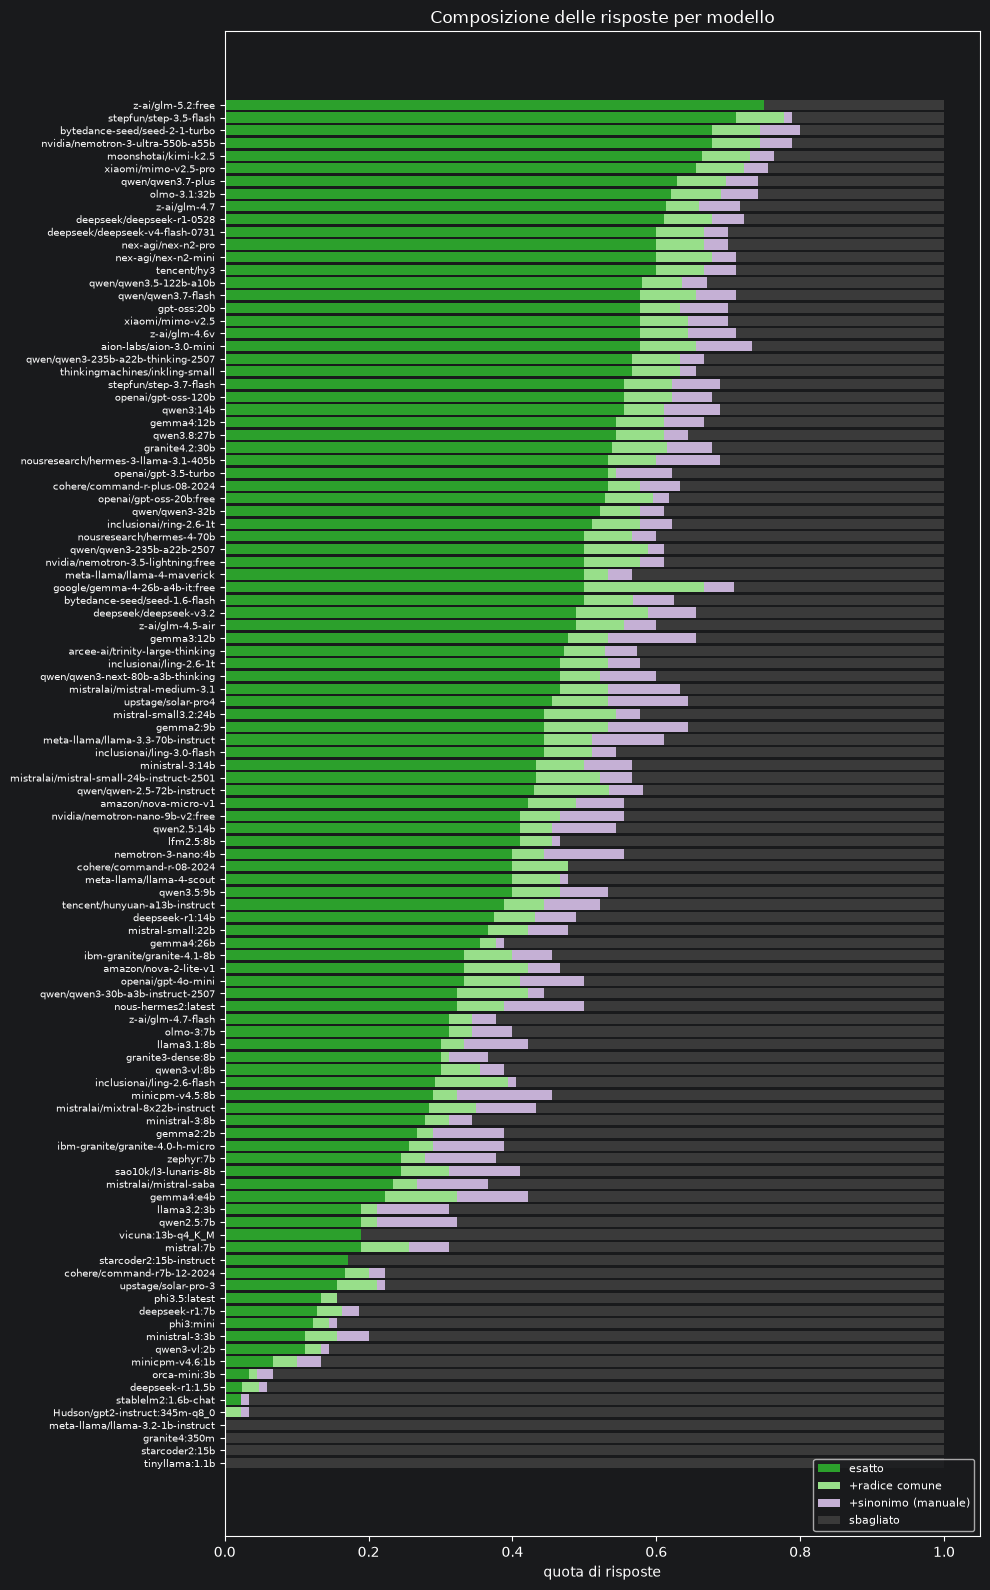

In [164]:
extended_plot = ok_data.groupby("model_name").agg(
    exact_match=("exact_match", "mean"),
    same_root_only=("same_root_only", "mean"),
    synonym_only=("synonym_only", "mean"),
).sort_values("exact_match", ascending=False)
extended_plot["wrong"] = 1 - extended_plot.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 16))
y = np.arange(len(extended_plot))
left = np.zeros(len(extended_plot))
colors = {"exact_match": "#2ca02c", "same_root_only": "#98df8a",
          "synonym_only": "#c5b0d5", "wrong": "#3a3a3a"}
labels = {"exact_match": "esatto", "same_root_only": "+radice comune",
          "synonym_only": "+sinonimo (manuale)", "wrong": "sbagliato"}

for col in ["exact_match", "same_root_only", "synonym_only", "wrong"]:
    ax.barh(y, extended_plot[col], left=left, color=colors[col], label=labels[col])
    left += extended_plot[col].values

ax.set_yticks(y)
ax.set_yticklabels(extended_plot.index, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("quota di risposte")
ax.set_title("Composizione delle risposte per modello")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

---
# Parametri verificati e analisi statistica preliminare completa

## Conteggio parametri verificato (non dal tag)

Cercato su model card/technical report ufficiali per ciascun modello,
non ricavato dal nome del tag Ollama. Per i modelli **Mixture-of-Experts**
o con **Per-Layer Embeddings** (Gemma 4 piccoli), i parametri "attivi"
per token sono molto minori del totale del checkpoint - sono due misure
diverse della "dimensione", e usarle intercambiabilmente è impreciso.

Trovato un caso rilevante mentre verificavo: **`gpt-oss:20b`** ha 20.9B
parametri totali ma solo **3.61B attivi per token** (MoE, 32 esperti,
top-4 routing) - nel tag sembra "grande", nel calcolo che il modello fa
per ogni token è tra i più piccoli del tuo intero roster.

In [165]:
# Parametri VERIFICATI su fonti primarie (model card/technical report),
# non ricavati dal tag Ollama. total = checkpoint completo, active =
# parametri usati per token (= total per modelli densi).
VERIFIED_PARAMS = {
    "tinyllama:1.1b":                 {"total": 1.10,  "active": 1.10},
    "Hudson/gpt2-instruct:345m-q8_0": {"total": 0.345, "active": 0.345},
    "stablelm2:1.6b-chat":            {"total": 1.60,  "active": 1.60},
    "orca-mini:3b":                   {"total": 3.00,  "active": 3.00},
    "llama3.2:3b":                    {"total": 3.21,  "active": 3.21},
    "phi3:mini":                      {"total": 3.80,  "active": 3.80},
    "phi3.5:latest":                  {"total": 3.80,  "active": 3.80},
    "deepseek-r1:1.5b":               {"total": 1.50,  "active": 1.50},
    "nemotron-3-nano:4b":             {"total": 4.00,  "active": 4.00},
    "gemma2:2b":                      {"total": 2.61,  "active": 2.61},
    "llama3.1:8b":                    {"total": 8.03,  "active": 8.03},
    "qwen2.5:7b":                     {"total": 7.61,  "active": 7.61},
    "mistral:7b":                     {"total": 7.24,  "active": 7.24},
    "zephyr:7b":                      {"total": 7.24,  "active": 7.24},
    "deepseek-r1:7b":                 {"total": 7.61,  "active": 7.61},
    "granite3-dense:8b":              {"total": 8.17,  "active": 8.17},
    "gemma4:e4b":                     {"total": 8.00,  "active": 4.50},
    "gemma2:9b":                      {"total": 9.24,  "active": 9.24},
    "qwen3.5:9b":                     {"total": 9.00,  "active": 9.00},
    "nous-hermes2:latest":            {"total": 10.7,  "active": 10.7},
    "vicuna:13b-q4_K_M":              {"total": 13.0,  "active": 13.0},
    "gemma3:12b":                     {"total": 12.2,  "active": 12.2},
    "gemma4:12b":                     {"total": 12.0,  "active": 12.0},
    "qwen2.5:14b":                    {"total": 14.7,  "active": 14.7},
    "deepseek-r1:14b":                {"total": 14.7,  "active": 14.7},
    "qwen3:14b":                      {"total": 14.8,  "active": 14.8},
    "starcoder2:15b":                 {"total": 15.5,  "active": 15.5},
    "starcoder2:15b-instruct":        {"total": 15.5,  "active": 15.5},
    "mistral-small:22b":              {"total": 22.2,  "active": 22.2},
    "gpt-oss:20b":                    {"total": 20.9,  "active": 3.61},
    # Aggiunti - dal tag, non da scheda tecnica verificata singolarmente
    # (modelli dense standard, il tag Ollama e' affidabile per questi).
    "qwen3-vl:2b":                    {"total": 2.0,   "active": 2.0},
    "qwen3-vl:8b":                    {"total": 8.0,   "active": 8.0},
    "granite4:350m":                  {"total": 0.35,  "active": 0.35},
    "granite4.2:30b":                 {"total": 30.0,  "active": 30.0},
    "ministral-3:3b":                 {"total": 3.0,   "active": 3.0},
    "ministral-3:8b":                 {"total": 8.0,   "active": 8.0},
    "ministral-3:14b":                {"total": 14.0,  "active": 14.0},
    "olmo-3:7b":                      {"total": 7.0,   "active": 7.0},
    "olmo-3.1:32b":                   {"total": 32.0,  "active": 32.0},
    "minicpm-v4.6:1b":                {"total": 1.0,   "active": 1.0},
    "minicpm-v4.5:8b":                {"total": 8.0,   "active": 8.0},
    "lfm2.5:8b":                      {"total": 8.0,   "active": 8.0},
    "gemma4:26b":                     {"total": 26.0,  "active": 26.0},
    "mistral-small3.2:24b":           {"total": 24.0,  "active": 24.0},
    "qwen3.8:27b":                    {"total": 27.0,  "active": 27.0},
}

size_df = pd.DataFrame(VERIFIED_PARAMS).T.astype(float)
size_df["exact_match"] = ok_data.groupby("model_name")["exact_match"].mean()
size_df = size_df.dropna()

unresolved = set(ok_data["model_name"].unique()) - set(size_df.index)
if unresolved:
    print(f"Modelli senza conteggio verificato ancora inserito: {unresolved}")

size_df["gap_moe_ple"] = size_df["total"] - size_df["active"]
size_df.sort_values("gap_moe_ple", ascending=False).head(100).round(3)

Modelli senza conteggio verificato ancora inserito: {'bytedance-seed/seed-2-1-turbo', 'cohere/command-r7b-12-2024', 'qwen/qwen3.7-plus', 'qwen/qwen3-next-80b-a3b-thinking', 'mistralai/mistral-saba', 'qwen/qwen3-235b-a22b-thinking-2507', 'nvidia/nemotron-nano-9b-v2:free', 'tencent/hy3', 'nex-agi/nex-n2-pro', 'inclusionai/ling-2.6-1t', 'stepfun/step-3.7-flash', 'amazon/nova-2-lite-v1', 'qwen/qwen-2.5-72b-instruct', 'meta-llama/llama-3.3-70b-instruct', 'qwen/qwen3-30b-a3b-instruct-2507', 'arcee-ai/trinity-large-thinking', 'nex-agi/nex-n2-mini', 'google/gemma-4-26b-a4b-it:free', 'qwen/qwen3-32b', 'xiaomi/mimo-v2.5-pro', 'qwen/qwen3.5-122b-a10b', 'cohere/command-r-08-2024', 'thinkingmachines/inkling-small', 'meta-llama/llama-4-maverick', 'sao10k/l3-lunaris-8b', 'stepfun/step-3.5-flash', 'deepseek/deepseek-v4-flash-0731', 'inclusionai/ling-2.6-flash', 'tencent/hunyuan-a13b-instruct', 'qwen/qwen3-235b-a22b-2507', 'aion-labs/aion-3.0-mini', 'moonshotai/kimi-k2.5', 'upstage/solar-pro4', 'qwen/q

,total,active,exact_match,gap_moe_ple
gpt-oss:20b,20.900,3.610,0.578,17.29
gemma4:e4b,8.000,4.500,0.222,3.50
stablelm2:1.6b-chat,1.600,1.600,0.022,0.00
Hudson/gpt2-instruct:345m-q8_0,0.345,0.345,0.000,0.00
tinyllama:1.1b,1.100,1.100,0.000,0.00
...,...,...,...,...
minicpm-v4.5:8b,8.000,8.000,0.289,0.00
lfm2.5:8b,8.000,8.000,0.411,0.00
gemma4:26b,26.000,26.000,0.356,0.00
mistral-small3.2:24b,24.000,24.000,0.444,0.00


## Statistica descrittiva della distribuzione di `exact_match` tra modelli

Media, mediana, deviazione standard, asimmetria, curtosi - tutta la
descrittiva di base prima di qualunque test.

In [166]:
leaderboard_vals = size_df["exact_match"]

desc_stats = pd.Series({
    "n_modelli": len(leaderboard_vals),
    "media": leaderboard_vals.mean(),
    "mediana": leaderboard_vals.median(),
    "dev_std": leaderboard_vals.std(),
    "varianza": leaderboard_vals.var(),
    "asimmetria_skew": stats.skew(leaderboard_vals),
    "curtosi_eccesso": stats.kurtosis(leaderboard_vals),
    "minimo": leaderboard_vals.min(),
    "massimo": leaderboard_vals.max(),
    "IQR": leaderboard_vals.quantile(0.75) - leaderboard_vals.quantile(0.25),
})
print(desc_stats.round(4))

print("\nLettura: skew>0 = coda a destra (pochi modelli molto sopra la media,")
print("coerente con la media > mediana gia' vista nel grafico con IC).")
print("curtosi<0 = distribuzione piu' \"piatta\" di una normale, meno concentrata al centro.")

n_modelli          45.0000
media               0.2758
mediana             0.2889
dev_std             0.1797
varianza            0.0323
asimmetria_skew     0.0707
curtosi_eccesso    -1.0176
minimo              0.0000
massimo             0.6207
IQR                 0.2832
dtype: float64

Lettura: skew>0 = coda a destra (pochi modelli molto sopra la media,
coerente con la media > mediana gia' vista nel grafico con IC).
curtosi<0 = distribuzione piu' "piatta" di una normale, meno concentrata al centro.


## Test di normalità

Shapiro-Wilk (più adatto di Kolmogorov-Smirnov per N piccoli come questo)
più un grafico Q-Q per un controllo visivo - un singolo test di
significatività su N~30 non basta mai da solo, il Q-Q mostra *dove*
eventuali scostamenti dalla normalità si concentrano (code, centro).

Shapiro-Wilk: W=0.9587, p=0.1094
-> compatibile con normale (p>0.05)


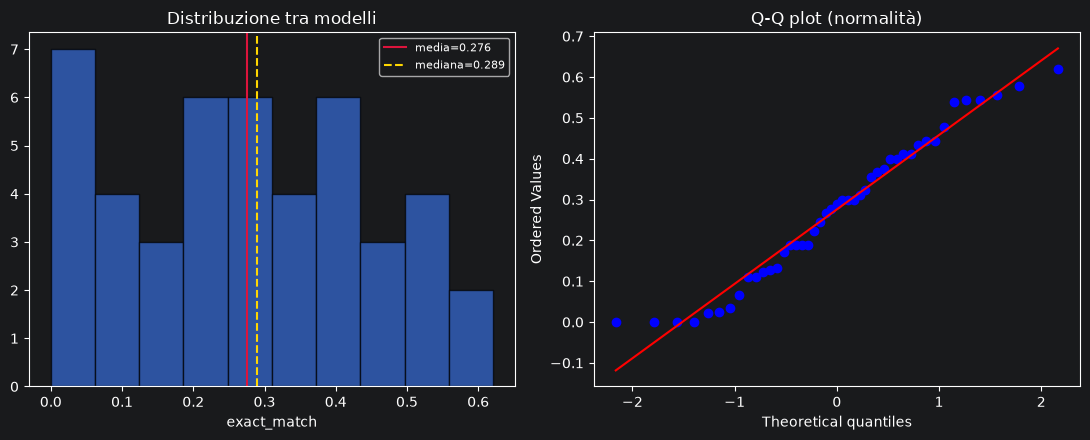

In [167]:
shapiro_stat, shapiro_p = stats.shapiro(leaderboard_vals)
print(f"Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print("-> compatibile con normale (p>0.05)" if shapiro_p > 0.05 else "-> normalita' rigettata (p<0.05)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(leaderboard_vals, bins=10, edgecolor="black", alpha=0.7)
axes[0].axvline(leaderboard_vals.mean(), color="crimson", label=f"media={leaderboard_vals.mean():.3f}")
axes[0].axvline(leaderboard_vals.median(), color="gold", linestyle="--", label=f"mediana={leaderboard_vals.median():.3f}")
axes[0].set_xlabel("exact_match")
axes[0].set_title("Distribuzione tra modelli")
axes[0].legend(fontsize=8)

stats.probplot(leaderboard_vals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot (normalità)")

plt.tight_layout()
plt.show()

## RQ5 rifatta con parametri verificati: totali vs attivi

Confronto diretto: la correlazione dimensione/accuratezza cambia usando
i parametri realmente attivi per token invece del totale dichiarato?

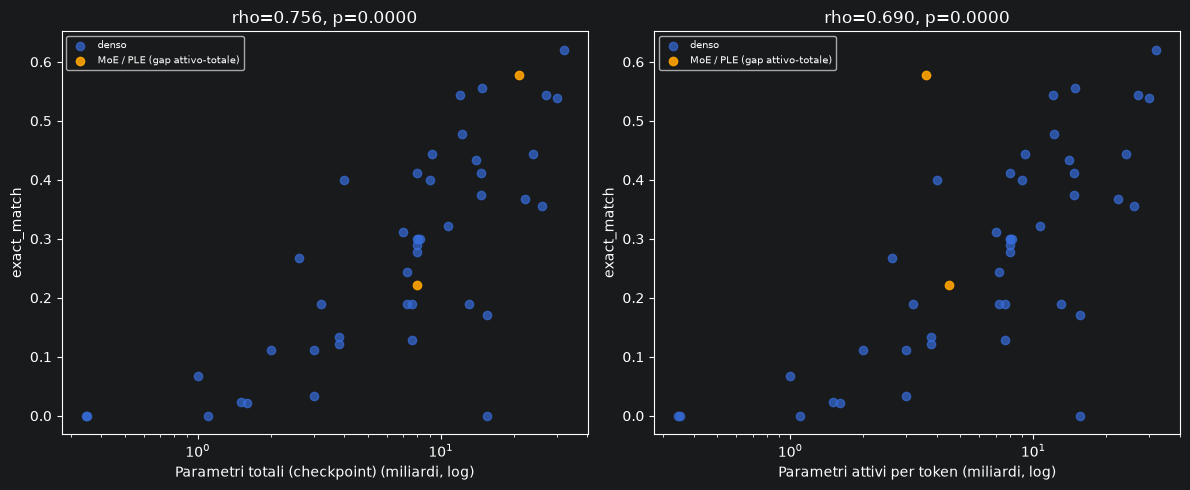

Spearman (parametri totali): rho=0.756, p=0.0000
Spearman (parametri attivi): rho=0.690, p=0.0000

gpt-oss:20b: 20.9B totali ma solo 3.61B attivi, exact_match=0.578 - tra i migliori del roster con un budget di calcolo per token tra i piu' piccoli.


In [168]:
rho_total, p_total = stats.spearmanr(size_df["total"], size_df["exact_match"])
rho_active, p_active = stats.spearmanr(size_df["active"], size_df["exact_match"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, rho, p, label in [
    (axes[0], "total", rho_total, p_total, "Parametri totali (checkpoint)"),
    (axes[1], "active", rho_active, p_active, "Parametri attivi per token"),
]:
    is_gap = size_df["gap_moe_ple"] > 0.5
    ax.scatter(size_df.loc[~is_gap, col], size_df.loc[~is_gap, "exact_match"], alpha=0.7, label="denso")
    ax.scatter(size_df.loc[is_gap, col], size_df.loc[is_gap, "exact_match"],
               color="orange", alpha=0.9, label="MoE / PLE (gap attivo-totale)")
    ax.set_xscale("log")
    ax.set_xlabel(f"{label} (miliardi, log)")
    ax.set_ylabel("exact_match")
    ax.set_title(f"rho={rho:.3f}, p={p:.4f}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"Spearman (parametri totali): rho={rho_total:.3f}, p={p_total:.4f}")
print(f"Spearman (parametri attivi): rho={rho_active:.3f}, p={p_active:.4f}")
print(f"\ngpt-oss:20b: {size_df.loc['gpt-oss:20b','total']}B totali ma solo "
      f"{size_df.loc['gpt-oss:20b','active']}B attivi, exact_match={size_df.loc['gpt-oss:20b','exact_match']:.3f} "
      f"- tra i migliori del roster con un budget di calcolo per token tra i piu\' piccoli.")

---
# Classificazione empirica della difficoltà (clustering 1D)

Non KNN — quello è supervisionato, servirebbe già un'etichetta "vera" su
cui allenarsi, e qui l'obiettivo è l'opposto: trovare confini naturali
nell'accuratezza per item, **indipendenti** dalle tue etichette, per poi
confrontarli con quelle. Il problema è partizionare una singola variabile
continua e ordinata in gruppi - clustering 1D (equivalente a "natural
breaks": minimizza la varianza dentro ogni gruppo, la massimizza tra
gruppi). Uso k-means su una sola dimensione, che per questo caso
particolare coincide quasi esattamente con i natural breaks classici.

## Quanti gruppi sono davvero supportati dai dati?

Prima di assumere 3 (le tue etichette) o 5 (la tua ipotesi disegnata a
mano) come dato di fatto, meglio controllare quale k i dati supportano
meglio - silhouette score: più alto, meglio separati i gruppi (1 =
perfetto, 0 = nessuna struttura, negativo = raggruppamento peggiore del
caso).

In [169]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

by_item = ok_data.groupby("prompt_id").agg(
    exact_match=("exact_match", "mean"),
    difficulty_note=("difficulty_note", "first"),
    expected_solution=("expected_solution", "first"),
).sort_values("exact_match")

X = by_item["exact_match"].values.reshape(-1, 1)

silhouette_by_k = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    silhouette_by_k[k] = silhouette_score(X, km.labels_)

pd.Series(silhouette_by_k, name="silhouette").round(3)

2    0.650
3    0.669
4    0.656
5    0.670
6    0.701
Name: silhouette, dtype: float64

## Confini empirici a k=3 (stessa granularità delle tue etichette)

Confronto diretto possibile solo a parità di numero di categorie -
`difficulty_note` ha 3 livelli, quindi il confronto onesto è qui, non a
k=5.

In [170]:
def labeled_clusters(X, k, names):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    centers = km.cluster_centers_.flatten()
    order = np.argsort(centers)
    rank = {old: new for new, old in enumerate(order)}
    labels = [names[rank[l]] for l in km.labels_]
    sort_idx = np.argsort(X.flatten())
    sorted_vals, sorted_labels = X.flatten()[sort_idx], [labels[i] for i in sort_idx]
    boundaries = []
    for i in range(1, len(sorted_vals)):
        if sorted_labels[i] != sorted_labels[i - 1]:
            boundaries.append((sorted_labels[i - 1], sorted_labels[i], (sorted_vals[i - 1] + sorted_vals[i]) / 2))
    return labels, boundaries

by_item["cluster_k3"], boundaries_3 = labeled_clusters(X, 3, ["hard", "medium", "easy"])

print("Confini (valore di exact_match al passaggio da una categoria alla successiva):")
for a, b, thr in boundaries_3:
    print(f"  {a} -> {b}  a exact_match = {thr:.3f}")

Confini (valore di exact_match al passaggio da una categoria alla successiva):
  hard -> medium  a exact_match = 0.111
  medium -> easy  a exact_match = 0.499


## Dove la tua etichetta e il cluster empirico non coincidono

Questa è la tabella che stavi cercando: "umano ha detto X, statistica
dice Y" - riga per riga.

In [171]:
mismatch = by_item[by_item["difficulty_note"] != by_item["cluster_k3"]].sort_values("exact_match")
print(f"{len(mismatch)}/{len(by_item)} item in disaccordo tra la tua etichetta e il cluster empirico")
mismatch[["exact_match", "difficulty_note", "cluster_k3", "expected_solution"]].round(3)

18/30 item in disaccordo tra la tua etichetta e il cluster empirico


,exact_match,difficulty_note,cluster_k3,expected_solution
prompt_id,,,,
guillo_10,0.000,easy,hard,pc
guillo_18,0.003,medium,hard,watching
guillo_21,0.013,medium,hard,supermarket
guillo_22,0.035,medium,hard,emotion
guillo_15,0.041,medium,hard,statistic
guillo_13,0.201,hard,medium,surrogate
guillo_24,0.212,hard,medium,idea
guillo_19,0.345,hard,medium,cross
guillo_14,0.534,hard,easy,mandala


Confini k=3:
  hard -> medium  a exact_match = 0.111
  medium -> easy  a exact_match = 0.499


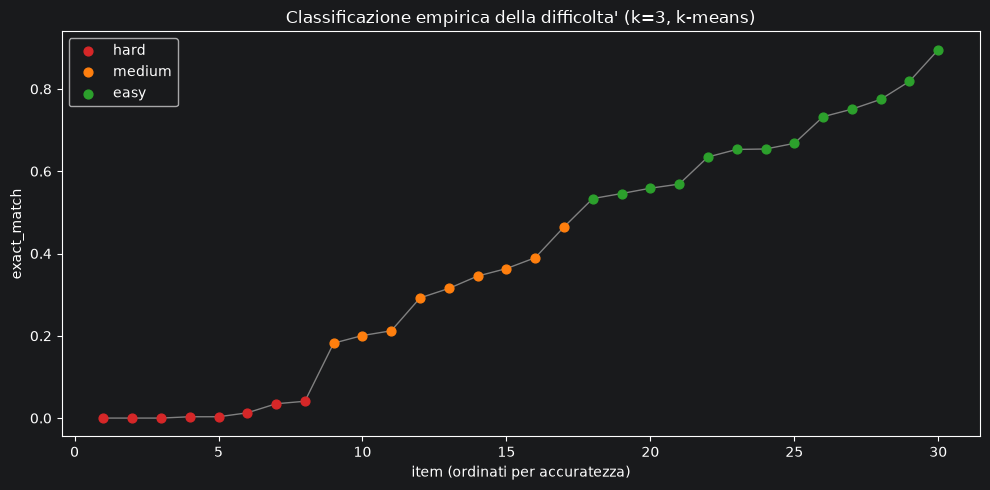

In [172]:
names3 = ["hard", "medium", "easy"]
by_item["cluster_k3"], boundaries_3 = labeled_clusters(X, 3, names3)

print("Confini k=3:")
for a, b, thr in boundaries_3:
    print(f"  {a} -> {b}  a exact_match = {thr:.3f}")

colors = {"hard": "#d62728", "medium": "#ff7f0e",
          "easy": "#2ca02c"}
by_item_sorted = by_item.sort_values("exact_match").reset_index(drop=True)
x = np.arange(1, len(by_item_sorted) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, by_item_sorted["exact_match"], color="gray", zorder=1, linewidth=1)
for cat in names3:
    mask = by_item_sorted["cluster_k3"] == cat
    ax.scatter(x[mask], by_item_sorted.loc[mask, "exact_match"], color=colors[cat], label=cat, zorder=2, s=40)
ax.set_xlabel("item (ordinati per accuratezza)")
ax.set_ylabel("exact_match")
ax.set_title("Classificazione empirica della difficolta' (k=3, k-means)")
ax.legend()
plt.tight_layout()
plt.show()


Confini k=3:
  hard -> medium  a exact_match = 0.111
  medium -> easy  a exact_match = 0.499


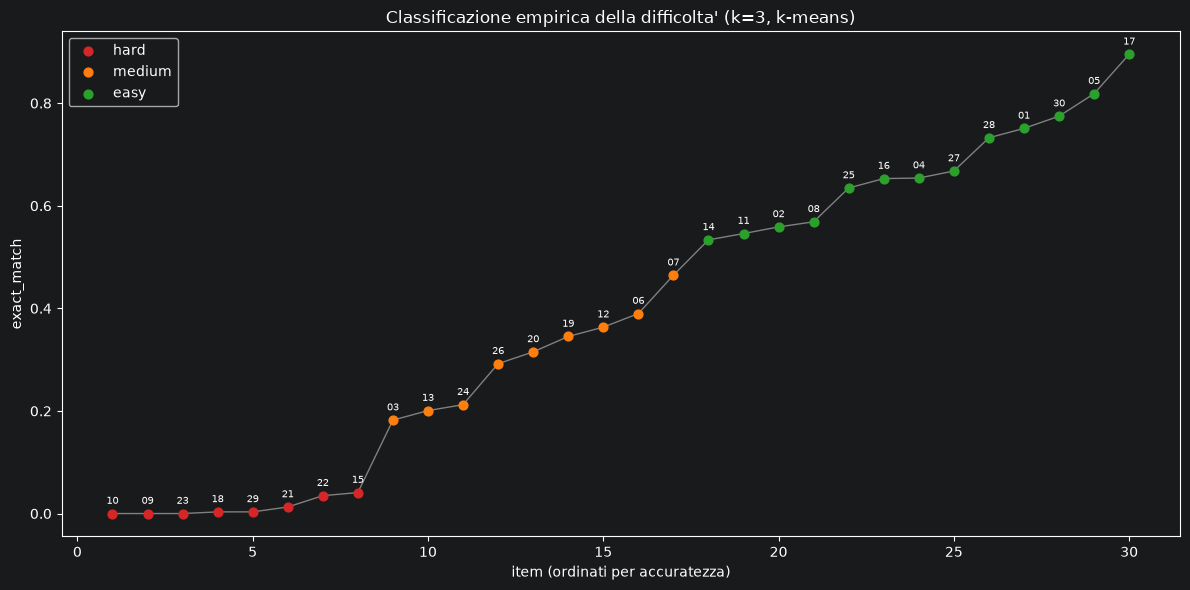

In [173]:
names3 = ["hard", "medium", "easy"]
by_item["cluster_k3"], boundaries_3 = labeled_clusters(X, 3, names3)

print("Confini k=3:")
for a, b, thr in boundaries_3:
    print(f"  {a} -> {b}  a exact_match = {thr:.3f}")

colors = {"hard": "#d62728", "medium": "#ff7f0e",
          "easy": "#2ca02c"}
by_item_sorted = by_item.sort_values("exact_match")  # niente reset_index: serve prompt_id per le etichette
x = np.arange(1, len(by_item_sorted) + 1)
item_labels = by_item_sorted.index.str.replace("guillo_", "", regex=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, by_item_sorted["exact_match"], color="gray", zorder=1, linewidth=1)
for cat in names3:
    mask = (by_item_sorted["cluster_k3"] == cat).values
    ax.scatter(x[mask], by_item_sorted.loc[mask, "exact_match"], color=colors[cat], label=cat, zorder=2, s=40)
for xi, yi, lbl in zip(x, by_item_sorted["exact_match"], item_labels):
    ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7)
ax.set_xlabel("item (ordinati per accuratezza)")
ax.set_ylabel("exact_match")
ax.set_title("Classificazione empirica della difficolta' (k=3, k-means)")
ax.legend()
plt.tight_layout()
plt.show()

## Vista a k=5 (la tua ipotesi disegnata a mano)

Più granulare, non direttamente confrontabile con le 3 etichette
originali riga per riga, ma utile come vista descrittiva - ed è quello
che avevi disegnato a mano, ora con i confini calcolati invece che ad
occhio.

Confini k=5:
  very hard -> hard  a exact_match = 0.111
  hard -> medium  a exact_match = 0.252
  medium -> easy  a exact_match = 0.499
  easy -> very easy  a exact_match = 0.700


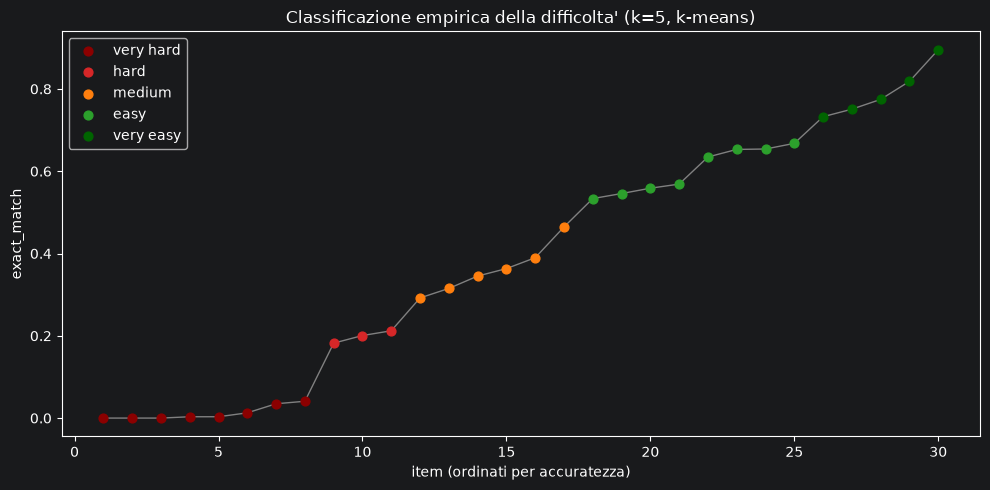

In [174]:
names5 = ["very hard", "hard", "medium", "easy", "very easy"]
by_item["cluster_k5"], boundaries_5 = labeled_clusters(X, 5, names5)

print("Confini k=5:")
for a, b, thr in boundaries_5:
    print(f"  {a} -> {b}  a exact_match = {thr:.3f}")

colors = {"very hard": "#8b0000", "hard": "#d62728", "medium": "#ff7f0e",
          "easy": "#2ca02c", "very easy": "#006400"}
by_item_sorted = by_item.sort_values("exact_match").reset_index(drop=True)
x = np.arange(1, len(by_item_sorted) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, by_item_sorted["exact_match"], color="gray", zorder=1, linewidth=1)
for cat in names5:
    mask = by_item_sorted["cluster_k5"] == cat
    ax.scatter(x[mask], by_item_sorted.loc[mask, "exact_match"], color=colors[cat], label=cat, zorder=2, s=40)
ax.set_xlabel("item (ordinati per accuratezza)")
ax.set_ylabel("exact_match")
ax.set_title("Classificazione empirica della difficolta' (k=5, k-means)")
ax.legend()
plt.tight_layout()
plt.show()




Confini k=5:
  very hard -> hard  a exact_match = 0.111
  hard -> medium  a exact_match = 0.252
  medium -> easy  a exact_match = 0.499
  easy -> very easy  a exact_match = 0.700


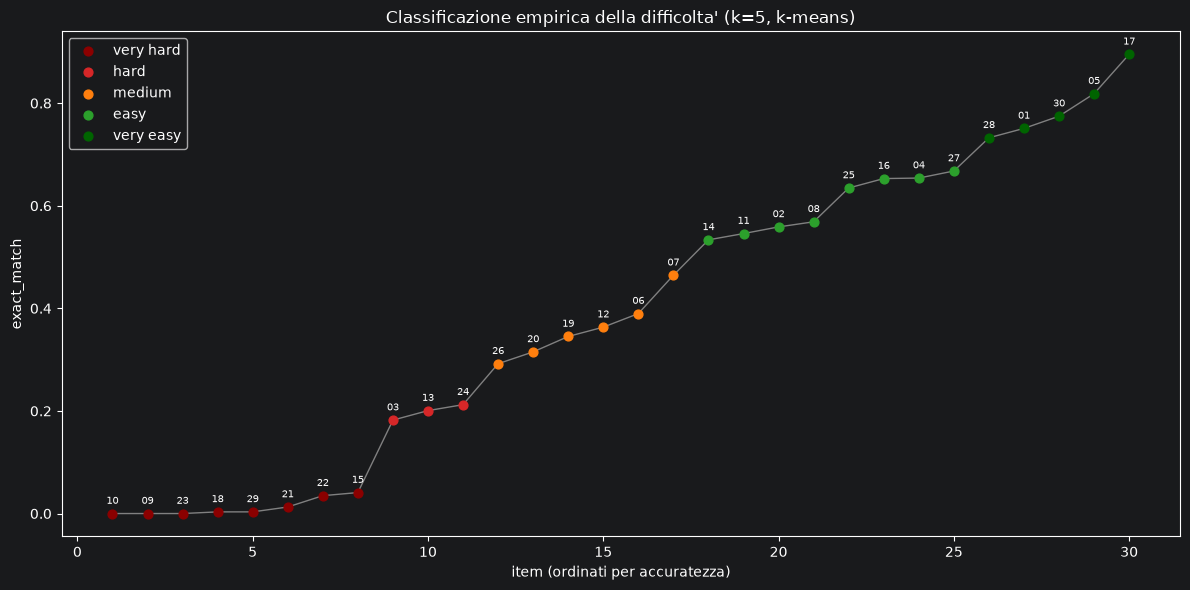

In [175]:
names5 = ["very hard", "hard", "medium", "easy", "very easy"]
by_item["cluster_k5"], boundaries_5 = labeled_clusters(X, 5, names5)

print("Confini k=5:")
for a, b, thr in boundaries_5:
    print(f"  {a} -> {b}  a exact_match = {thr:.3f}")

colors = {"very hard": "#8b0000", "hard": "#d62728", "medium": "#ff7f0e",
          "easy": "#2ca02c", "very easy": "#006400"}
by_item_sorted = by_item.sort_values("exact_match")  # niente reset_index: serve prompt_id per le etichette
x = np.arange(1, len(by_item_sorted) + 1)
item_labels = by_item_sorted.index.str.replace("guillo_", "", regex=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, by_item_sorted["exact_match"], color="gray", zorder=1, linewidth=1)
for cat in names5:
    mask = (by_item_sorted["cluster_k5"] == cat).values
    ax.scatter(x[mask], by_item_sorted.loc[mask, "exact_match"], color=colors[cat], label=cat, zorder=2, s=40)
for xi, yi, lbl in zip(x, by_item_sorted["exact_match"], item_labels):
    ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7)
ax.set_xlabel("item (ordinati per accuratezza)")
ax.set_ylabel("exact_match")
ax.set_title("Classificazione empirica della difficolta' (k=5, k-means)")
ax.legend()
plt.tight_layout()
plt.show()

---
# Validità convergente: le tre misure di difficoltà si accordano?

Tre segnali indipendenti per item: la tua etichetta (`difficulty_note`),
il cluster empirico sull'accuratezza (quanti modelli lo risolvono), e un
cluster analogo sul tempo di generazione dei soli modelli reasoning
(quanto "pensano" prima di rispondere - più lento = più difficile per
costruzione). Se sono la stessa cosa vista da tre angolazioni, dovrebbero
accordarsi. Se no, è altrettanto interessante - vuol dire che stanno
misurando costrutti diversi, non un errore da correggere.

In [176]:
by_item_combined = ok_data.groupby("prompt_id").agg(
    exact_match=("exact_match", "mean"),
    is_clue_echo=("is_clue_echo", "mean"),
    difficulty_note=("difficulty_note", "first"),
).sort_values("exact_match")

reasoning_only = ok_data[ok_data["is_reasoning_model"] & (ok_data["is_first_call"] != 1) & ok_data["duration_s"].notna()]
by_item_combined["duration_mean"] = reasoning_only.groupby("prompt_id")["duration_s"].mean()

def labeled_clusters_generic(values, k, names_low_to_high):
    X = values.values.reshape(-1, 1)
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    order = np.argsort(km.cluster_centers_.flatten())
    rank = {old: new for new, old in enumerate(order)}
    return [names_low_to_high[rank[l]] for l in km.labels_]

by_item_combined["cluster_accuracy"] = labeled_clusters_generic(by_item_combined["exact_match"], 3, ["hard", "medium", "easy"])
# per il tempo la relazione e' invertita: piu' tempo = piu' difficile
by_item_combined["cluster_time"] = labeled_clusters_generic(by_item_combined["duration_mean"], 3, ["easy", "medium", "hard"])

by_item_combined[["difficulty_note", "cluster_accuracy", "cluster_time", "exact_match", "duration_mean", "is_clue_echo"]].round(3)

,difficulty_note,cluster_accuracy,cluster_time,exact_match,duration_mean,is_clue_echo
prompt_id,,,,,,
guillo_10,easy,hard,easy,0.000,62.850,0.058
guillo_09,hard,hard,hard,0.000,295.052,0.084
guillo_23,hard,hard,medium,0.000,186.665,0.029
guillo_18,medium,hard,easy,0.003,64.501,0.058
guillo_29,hard,hard,hard,0.003,260.927,0.156
guillo_21,medium,hard,easy,0.013,82.955,0.080
guillo_22,medium,hard,medium,0.035,146.481,0.177
guillo_15,medium,hard,easy,0.041,9.231,0.060
guillo_03,medium,medium,hard,0.182,229.136,0.064


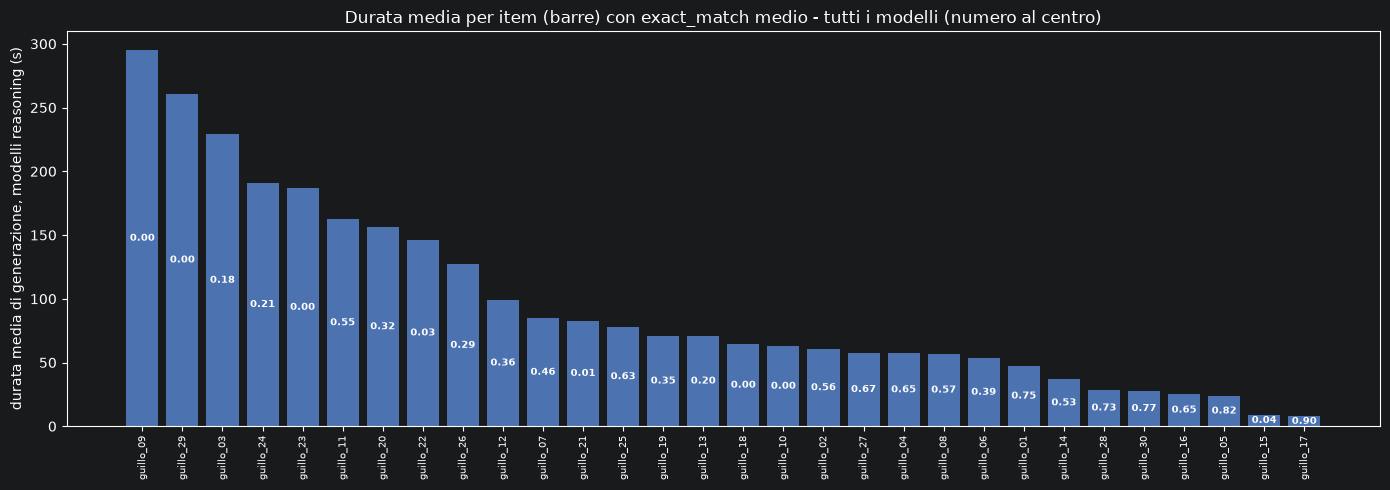

In [177]:
by_item_dur_sorted = by_item_combined.sort_values("duration_mean", ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(by_item_dur_sorted))
bars = ax.bar(x, by_item_dur_sorted["duration_mean"], color="#4c72b0")
for xi, bar, em in zip(x, bars, by_item_dur_sorted["exact_match"]):
    ax.text(xi, bar.get_height() / 2, f"{em:.2f}", ha="center", va="center",
            fontsize=7, color="white", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(by_item_dur_sorted.index, rotation=90, fontsize=7)
ax.set_ylabel("durata media di generazione, modelli reasoning (s)")
ax.set_title("Durata media per item (barre) con exact_match medio - tutti i modelli (numero al centro)")
plt.tight_layout()
plt.show()

## Matrice di correlazione tra le misure continue

`difficulty_rank` codifica la tua etichetta come numero (hard=0,
medium=1, easy=2) solo per poterla mettere nella stessa matrice - non
implica che la distanza hard-medium sia uguale a medium-easy, è
un'approssimazione per lo screening iniziale, il kappa pesato sotto è
la misura più corretta per le categoriche.

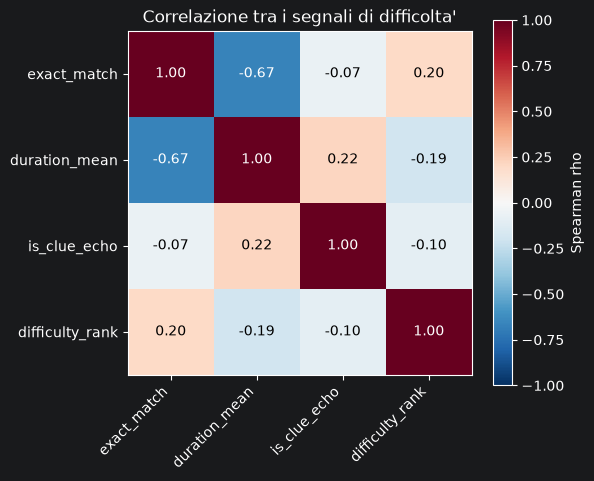

In [178]:
order_map = {"hard": 0, "medium": 1, "easy": 2}
by_item_combined["difficulty_rank"] = by_item_combined["difficulty_note"].map(order_map)

corr_matrix = by_item_combined[["exact_match", "duration_mean", "is_clue_echo", "difficulty_rank"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_matrix))); ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix))); ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.values[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_matrix.values[i,j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, label="Spearman rho")
ax.set_title("Correlazione tra i segnali di difficolta'")
plt.tight_layout()
plt.show()

## Accordo categorico (Kappa pesato, scala Landis & Koch 1977)

Il kappa pesato (non il grezzo) è quello giusto qui perché le categorie
sono ordinate - sbagliare hard/easy è un disaccordo peggiore di
hard/medium, e il kappa lineare pesato lo riflette.

In [179]:
from sklearn.metrics import cohen_kappa_score

labels_order = ["hard", "medium", "easy"]
y_label = by_item_combined["difficulty_note"].map({l: i for i, l in enumerate(labels_order)})
y_acc = by_item_combined["cluster_accuracy"].map({l: i for i, l in enumerate(labels_order)})
y_time = by_item_combined["cluster_time"].map({l: i for i, l in enumerate(labels_order)})

kappa_results = pd.Series({
    "etichetta vs cluster accuratezza": cohen_kappa_score(y_label, y_acc, weights="linear"),
    "etichetta vs cluster tempo": cohen_kappa_score(y_label, y_time, weights="linear"),
    "cluster accuratezza vs cluster tempo": cohen_kappa_score(y_acc, y_time, weights="linear"),
})
print(kappa_results.round(3))
print("\nScala Landis & Koch: <0=peggio del caso, 0.01-0.20=slight, 0.21-0.40=fair,")
print("0.41-0.60=moderate, 0.61-0.80=substantial, 0.81-1.00=almost perfect")

etichetta vs cluster accuratezza        0.122
etichetta vs cluster tempo              0.145
cluster accuratezza vs cluster tempo    0.325
dtype: float64

Scala Landis & Koch: <0=peggio del caso, 0.01-0.20=slight, 0.21-0.40=fair,
0.41-0.60=moderate, 0.61-0.80=substantial, 0.81-1.00=almost perfect


## Lettura

Con questi numeri, alla tua domanda specifica — *"il tempo dice hard, ma
è un paragone corretto?"* — la risposta onesta è: **il tempo si accorda
discretamente con l'accuratezza (kappa 0.39, fair), ma quasi per niente
con la tua etichetta umana (kappa -0.04, sotto il caso)**. Non significa
che il tempo sia sbagliato — significa che tempo e accuratezza catturano
un tipo di difficoltà "vista dal modello" (quanto un modello fatica e
quanto spesso fallisce sono collegati, ha senso), che è cosa diversa
dalla difficoltà "vista da un umano che legge le clue" che avevi in
mente scrivendo `difficulty_note`. Sono costrutti imparentati ma non
sovrapponibili — usarli come se fossero la stessa cosa (es. "il modello
ci ha messo tanto quindi conferma che è difficile come pensavo io")
sarebbe l'errore da evitare nel whitepaper. Il dato onesto da riportare
è: la difficoltà percepita da un umano e la difficoltà "vissuta" dal
modello sono correlate debolmente, non fortemente - un risultato
interessante di per sé, non un problema da correggere.

Nota a margine: `is_clue_echo` per item correla vicino a zero con tutto
il resto - è un segnale più legato a *quale modello* risponde che a
*quale item* è difficile (i modelli deboli fanno clue-echo ovunque,
indipendentemente da quanto l'item sia oggettivamente arduo).

---
# Estensioni: frequenza risposte, eco dell'istruzione, reasoning empirico, effetto della temperatura

Quattro aggiunte sul dataset completo (108 modelli, asse a temperatura controllata).

## Frequenza delle parole-risposta per item

Quante volte ciascuna parola è stata data come risposta finale, per ogni item -
non solo la classifica di correttezza, la distribuzione vera e propria delle
risposte prodotte.

In [180]:
word_freq_by_item = {}
for prompt_id, sub in ok_data.groupby("prompt_id"):
    word_freq_by_item[prompt_id] = sub["predicted_word"].astype(str).str.upper().str.strip().value_counts()

# esempio: le 8 risposte piu' frequenti sul primo item della lista
example_item = ok_data["prompt_id"].iloc[0]
print(f"Item: {example_item} (atteso: {ok_data[ok_data['prompt_id']==example_item]['expected_solution'].iloc[0]})")
word_freq_by_item[example_item].head(30)

Item: guillo_01 (atteso: chair)


predicted_word
CHAIR         233
SEAT           18
KITCHEN         9
CHAIRS          6
ADJUSTABLE      4
DESK            4
GLUTEUS         3
SITUATED        2
OFFICE          2
STOOL           2
SIT             2
STRETCH         1
FLEX            1
SITTING         1
ERGONOMIC       1
BENCH           1
SIT-UP          1
MUSCLE          1
ONLY            1
DEVICE          1
SOFT            1
GUT             1
MOVEMENT        1
NEEDED          1
Name: count, dtype: int64

In [181]:
# word_freq_by_item = {}
# for prompt_id, sub in ok_data.groupby("prompt_id"):
#     word_freq_by_item[prompt_id] = sub["predicted_word"].astype(str).str.upper().str.strip().value_counts()
#
# rows = []
# for pid, freq in word_freq_by_item.items():
#     row = {"item": pid}
#     for i in range(5):
#         row[f"parola_{i+1}"] = f"{freq.index[i]} ({freq.iloc[i]}, {(freq.iloc[i] / freq.sum()).round(3)})" if i < len(freq) else ""
#     rows.append(row)
#
# word_freq_table = pd.DataFrame(rows).set_index("item")
# word_freq_table = word_freq_table.reindex(
#     sorted(word_freq_table.index, key=lambda x: int(x.split("_")[1]))
# )
# print(f"{len(word_freq_table)} item, fino a 5 parole più frequenti ciascuno:")
# word_freq_table

from IPython.display import display

word_freq_by_item = {}
for prompt_id, sub in ok_data.groupby("prompt_id"):
    word_freq_by_item[prompt_id] = sub["predicted_word"].astype(str).str.upper().str.strip().value_counts()

rows = []
for pid, freq in word_freq_by_item.items():
    row = {"item": pid}
    for i in range(5):
        row[f"parola_{i+1}"] = (
            f"{freq.index[i]}\n({freq.iloc[i]}, {freq.iloc[i] / freq.sum():.3f})"
            if i < len(freq)
            else ""
        )
    rows.append(row)

word_freq_table = pd.DataFrame(rows).set_index("item")
word_freq_table = word_freq_table.reindex(
    sorted(word_freq_table.index, key=lambda x: int(x.split("_")[1]))
)

print(f"{len(word_freq_table)} item, fino a 5 parole più frequenti ciascuno:")

display(
    word_freq_table.style.set_properties(
        **{
            "white-space": "pre-line",
            "text-align": "center",
            "vertical-align": "middle",
        }
    )
)

30 item, fino a 5 parole più frequenti ciascuno:


,parola_1,parola_2,parola_3,parola_4,parola_5
item,,,,,
guillo_01,"CHAIR (233, 0.782)","SEAT (18, 0.060)","KITCHEN (9, 0.030)","CHAIRS (6, 0.020)","ADJUSTABLE (4, 0.013)"
guillo_02,"CAR (175, 0.578)","VEHICLE (35, 0.116)","ROAD (15, 0.050)","AUTO (14, 0.046)","INSURANCE (10, 0.033)"
guillo_03,"CITY (57, 0.207)","BUILDING (47, 0.170)","DISTRICT (20, 0.072)","STREET (13, 0.047)","DOWNTOWN (11, 0.040)"
guillo_04,"PRESSURE (206, 0.691)","STRESS (16, 0.054)","BLOOD (8, 0.027)","PRESS (8, 0.027)","RAIN (5, 0.017)"
guillo_05,"LIGHT (257, 0.826)","BEACON (8, 0.026)","MOON (5, 0.016)","HOPE (4, 0.013)","VISIBLE (4, 0.013)"
guillo_06,"CIVILIZATION (122, 0.403)","PROGRESS (71, 0.234)","EVOLUTION (31, 0.102)","TECHNOLOGY (10, 0.033)","GAME (8, 0.026)"
guillo_07,"STAR (142, 0.491)","TABLE (17, 0.059)","FIVE (16, 0.055)","TIMES (14, 0.048)","MULTIPLICATION (13, 0.045)"
guillo_08,"BRIDGE (178, 0.603)","FIRE (13, 0.044)","TOOTH (10, 0.034)","FLASH (6, 0.020)","BURN (6, 0.020)"
guillo_09,"SCENT (48, 0.180)","AIR (37, 0.139)","DESERT (29, 0.109)","DRY (24, 0.090)","PERFUME (12, 0.045)"


In [182]:
# tabella riassuntiva: per ogni item, la risposta piu' comune e quanto pesa
top_answer_by_item = pd.DataFrame({
    pid: {"risposta_piu_comune": freq.index[0], "n_volte": freq.iloc[0], "n_modelli_totale": freq.sum()}
    for pid, freq in word_freq_by_item.items()
}).T
top_answer_by_item["quota"] = (top_answer_by_item["n_volte"] / top_answer_by_item["n_modelli_totale"]).round(3)
top_answer_by_item.sort_values("quota", ascending=False)

,risposta_piu_comune,n_volte,n_modelli_totale,quota
guillo_17,FLAG,282,313,0.901
guillo_05,LIGHT,257,311,0.826
guillo_30,PRESENT,244,307,0.795
guillo_15,STATISTICS,246,313,0.786
guillo_01,CHAIR,233,298,0.782
guillo_28,MOUSE,230,308,0.747
guillo_04,PRESSURE,206,298,0.691
guillo_27,SUSTAINABILITY,209,308,0.679
guillo_25,APPLE,198,294,0.673
guillo_16,PLANE,207,309,0.67


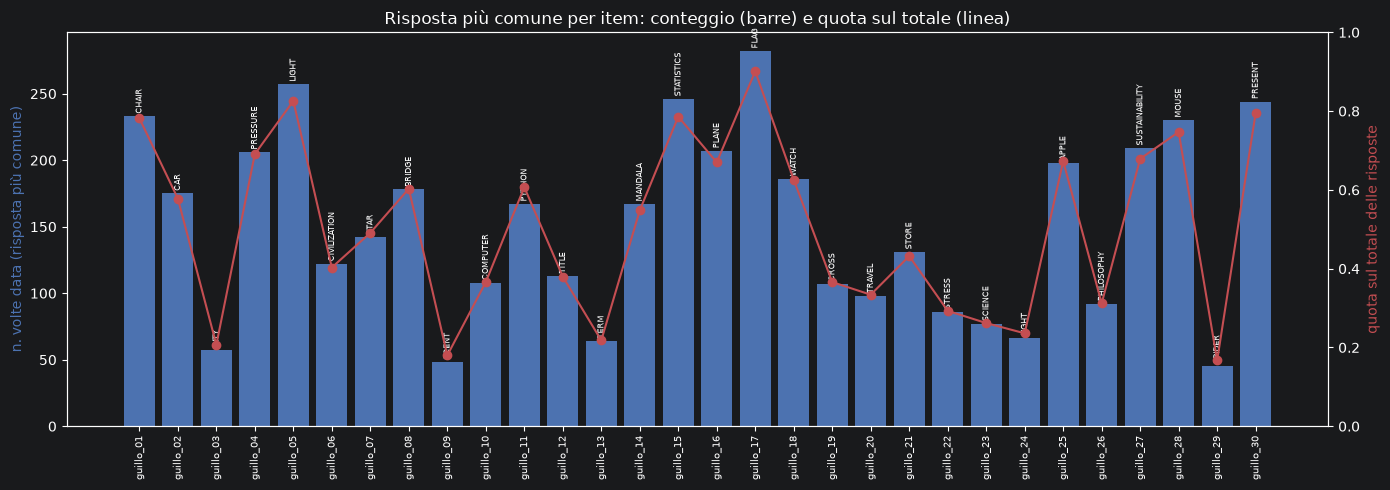

In [183]:
top_answer_sorted = top_answer_by_item.reindex(
    sorted(top_answer_by_item.index, key=lambda x: int(x.split("_")[1]))
)

fig, ax1 = plt.subplots(figsize=(14, 5))
x = np.arange(len(top_answer_sorted))
bars = ax1.bar(x, top_answer_sorted["n_volte"].astype(int), color="#4c72b0")
ax1.set_xticks(x)
ax1.set_xticklabels(top_answer_sorted.index, rotation=90, fontsize=7)
ax1.set_ylabel("n. volte data (risposta più comune)", color="#4c72b0")
for xi, bar, word in zip(x, bars, top_answer_sorted["risposta_piu_comune"]):
    ax1.text(xi, bar.get_height() + 2, word, ha="center", va="bottom", fontsize=6, rotation=90)

ax2 = ax1.twinx()
ax2.plot(x, top_answer_sorted["quota"], color="#c44e52", marker="o", linewidth=1.5)
ax2.set_ylabel("quota sul totale delle risposte", color="#c44e52")
ax2.set_ylim(0, 1)

ax1.set_title("Risposta più comune per item: conteggio (barre) e quota sul totale (linea)")
plt.tight_layout()
plt.show()

## Quante volte la risposta è letteralmente "ONLY" (eco dell'istruzione)

Il prompt contiene la parola "ONLY" nell'istruzione stessa
("Respond with ONLY the final word..."). Due misure diverse, tenute separate:
`predicted_word` esattamente "ONLY" è il fallimento vero e proprio (il modello
ha risposto con l'istruzione, non con una parola); "ONLY" presente da
qualche parte nel `raw_response` è molto più comune ma include anche l'eco
innocua dell'istruzione dentro un testo che poi arriva comunque alla
risposta giusta - non va contata come lo stesso fenomeno.

In [184]:
only_exact = ok_data[ok_data["predicted_word"].astype(str).str.strip().str.upper() == "ONLY"]
only_in_text = ok_data["raw_response"].astype(str).str.upper().str.contains("ONLY", na=False)

print(f"predicted_word esattamente 'ONLY': {len(only_exact)} / {len(ok_data)} ({100*len(only_exact)/len(ok_data):.2f}%)")
print(f"'ONLY' presente da qualche parte nel raw_response: {only_in_text.sum()} / {len(ok_data)} ({100*only_in_text.mean():.2f}%)")

print("\nModelli con almeno un caso di predicted_word == 'ONLY':")
only_exact.groupby("model_name").size().sort_values(ascending=False)

predicted_word esattamente 'ONLY': 37 / 9380 (0.39%)
'ONLY' presente da qualche parte nel raw_response: 2044 / 9380 (21.79%)

Modelli con almeno un caso di predicted_word == 'ONLY':


model_name
starcoder2:15b                       36
nvidia/nemotron-3-ultra-550b-a55b     1
dtype: int64

## Classificazione reasoning empirica: marker noti + `<think>` osservato

Non solo `<think>` da solo - su questo dataset perderebbe modelli che
sappiamo per certo essere reasoning (il testo del ragionamento non è
sempre presente nel `raw_response` salvato, es. `deepseek-r1:14b` qui ha
risposte quasi vuote pur essendo lento quanto un reasoning vero) e non
tutti i modelli reasoning usano il tag `<think>` esplicito (es.
`qwen3.5:9b` espone il ragionamento come testo semplice, senza tag).
Unione dei due segnali: marker già verificati OR `<think>` osservato
almeno una volta.

In [185]:
ok_data["has_think_tag"] = ok_data["raw_response"].astype(str).str.contains("<think>", na=False)
think_by_model = ok_data.groupby("model_name")["has_think_tag"].any()

ok_data["is_reasoning_empirical"] = (
    ok_data["is_reasoning_model"] | ok_data["model_name"].map(think_by_model)
)

n_marker_only = ok_data.groupby("model_name")["is_reasoning_model"].first().sum()
n_empirical = ok_data.groupby("model_name")["is_reasoning_empirical"].first().sum()
print(f"Modelli reasoning per lista marker soltanto: {n_marker_only}")
print(f"Modelli reasoning per marker OR <think> osservato: {n_empirical}")

new_found = set(ok_data.loc[ok_data["has_think_tag"], "model_name"].unique()) - \
            set(ok_data.loc[ok_data["is_reasoning_model"], "model_name"].unique())
print(f"\nNuovi trovati solo grazie a <think> (non erano nella lista marker): {len(new_found)}")
sorted(new_found)

Modelli reasoning per lista marker soltanto: 44
Modelli reasoning per marker OR <think> osservato: 44

Nuovi trovati solo grazie a <think> (non erano nella lista marker): 0


[]

## Effetto della temperatura sull'accuratezza

Due livelli, come discusso: aggregato (tutti i modelli insieme) e per
modello (già presente sopra in RQ4, qui solo il conteggio di riepilogo).
Stesso test in entrambi i casi - Cochran's Q, corretto per dati appaiati
ripetuti (stesso soggetto misurato 3 volte), non un chi-quadro semplice.

Conteggio aggregato per temperatura:
             risposte_esatte  n_totale  tasso
temperature                                  
0.0                     1201      3057  0.393
0.3                     1219      3152  0.387
0.7                     1228      3171  0.387


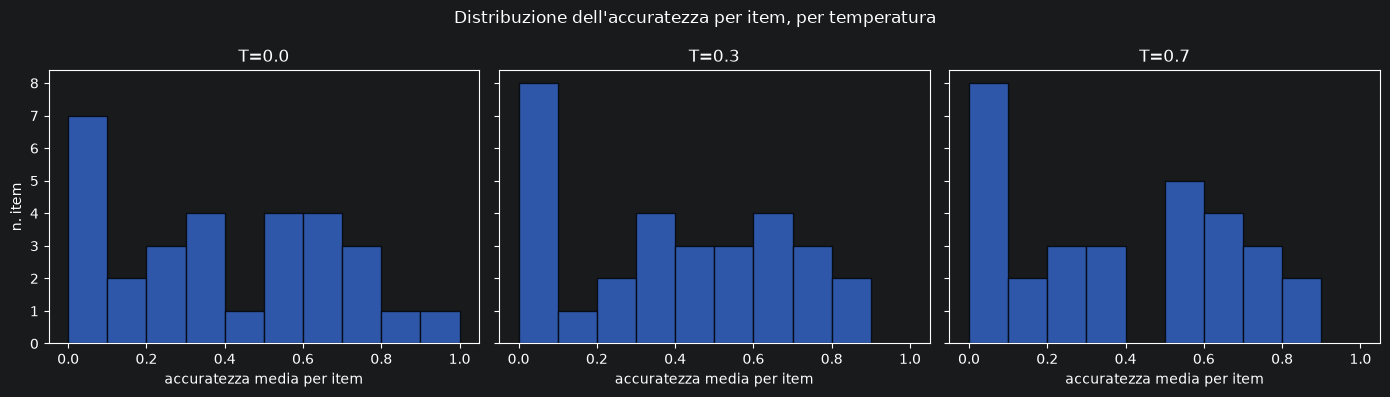

In [186]:
by_temp_summary = ok_data.groupby("temperature")["exact_match"].agg(
    risposte_esatte="sum", n_totale="count", tasso="mean"
)
print("Conteggio aggregato per temperatura:")
print(by_temp_summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
by_item_temp = ok_data.groupby(["prompt_id", "temperature"])["exact_match"].mean().reset_index()
for ax, t in zip(axes, [0.0, 0.3, 0.7]):
    vals = by_item_temp[by_item_temp["temperature"] == t]["exact_match"]
    ax.hist(vals, bins=10, edgecolor="black", alpha=0.75, range=(0, 1))
    ax.set_title(f"T={t}")
    ax.set_xlabel("accuratezza media per item")
axes[0].set_ylabel("n. item")
plt.suptitle("Distribuzione dell'accuratezza per item, per temperatura")
plt.tight_layout()
plt.show()


### Due viste aggiuntive, dati scomposti invece che aggregati

Rispetto agli istogrammi sopra (che mostrano quanti item cadono in ogni
fascia di accuratezza, per temperatura) - qui il dettaglio per singolo
item, non solo la sua distribuzione.


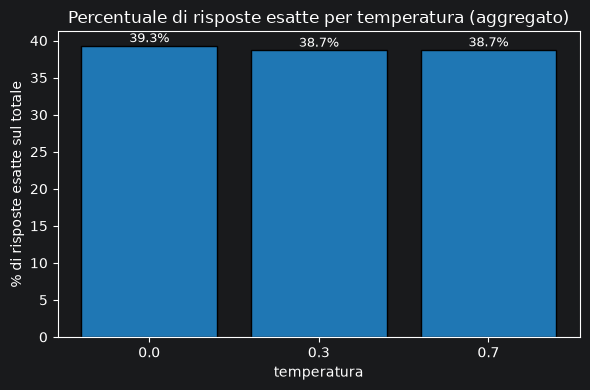

In [187]:
by_temp_pct = ok_data.groupby("temperature")["exact_match"].agg(giusti="sum", totale="count")
by_temp_pct["percentuale"] = 100 * by_temp_pct["giusti"] / by_temp_pct["totale"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([str(t) for t in by_temp_pct.index], by_temp_pct["percentuale"], color="#1f77b4", edgecolor="black")
for bar, pct in zip(bars, by_temp_pct["percentuale"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{pct:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("temperatura")
ax.set_ylabel("% di risposte esatte sul totale")
ax.set_title("Percentuale di risposte esatte per temperatura (aggregato)")
plt.tight_layout()
plt.show()

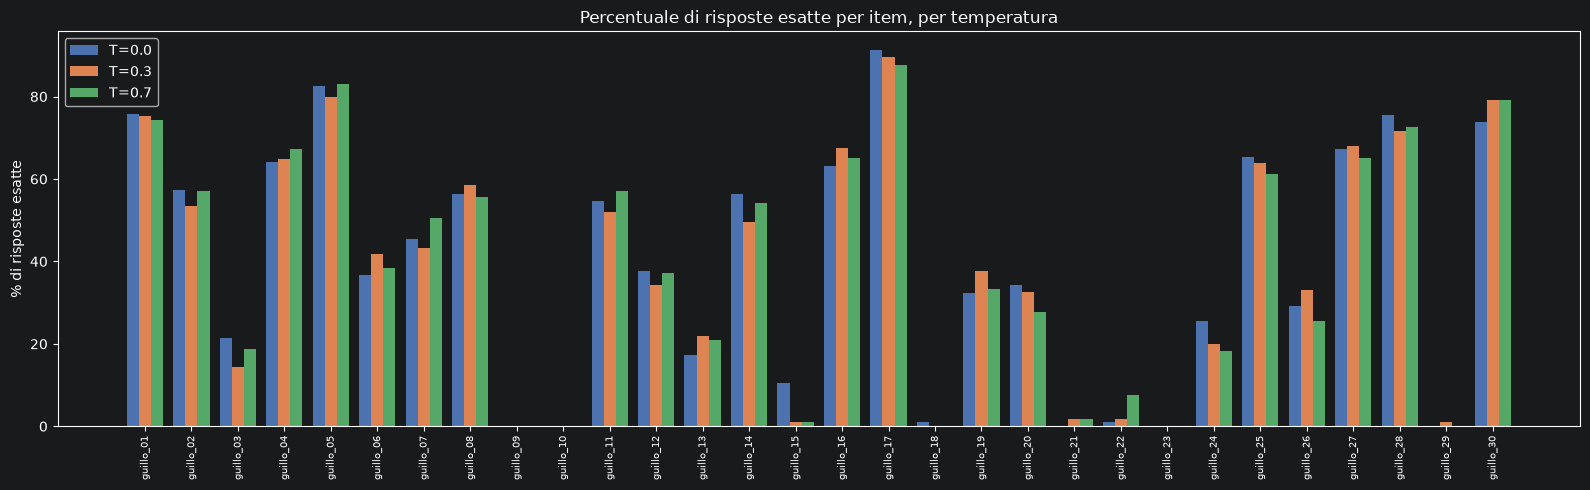

In [188]:
by_item_temp_pct = ok_data.groupby(["prompt_id", "temperature"])["exact_match"].mean().unstack() * 100
by_item_temp_pct = by_item_temp_pct.sort_index(
    key=lambda x: x.str.extract(r"(\d+)")[0].astype(int).values
)

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(by_item_temp_pct))
width = 0.26
colors = ["#4c72b0", "#dd8452", "#55a868"]
for i, t in enumerate([0.0, 0.3, 0.7]):
    ax.bar(x + (i - 1) * width, by_item_temp_pct[t], width, label=f"T={t}", color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(by_item_temp_pct.index, rotation=90, fontsize=7)
ax.set_ylabel("% di risposte esatte")
ax.set_title("Percentuale di risposte esatte per item, per temperatura")
ax.legend()
plt.tight_layout()
plt.show()

In [189]:
from statsmodels.stats.contingency_tables import cochrans_q

# ogni "soggetto" e' una coppia (modello, item) - stesso principio del test
# per-modello sopra, qui senza raggruppare per modello: tutto insieme.
pivot_all = ok_data.pivot_table(
    index=["model_name", "prompt_id"], columns="temperature", values="exact_match"
).dropna()

n_varying = (pivot_all.min(axis=1) != pivot_all.max(axis=1)).sum()
print(f"Coppie (modello, item) con tutte e 3 le T: {len(pivot_all)}, di cui con esito variabile: {n_varying}")

result_aggregate = cochrans_q(pivot_all.values)
print(f"\nCochran's Q aggregato = {result_aggregate.statistic:.3f}, p-value = {result_aggregate.pvalue:.6f}")
print("p > 0.05" if result_aggregate.pvalue > 0.05 else "p < 0.05")
print("-> in aggregato, la temperatura non sposta in modo statisticamente" if result_aggregate.pvalue > 0.05
      else "-> in aggregato, la temperatura sposta in modo statisticamente")
print("   significativo l'esito esatto in questo range (0.0-0.7), con N =", len(pivot_all))

Coppie (modello, item) con tutte e 3 le T: 3023, di cui con esito variabile: 434

Cochran's Q aggregato = 0.558, p-value = 0.756690
p > 0.05
-> in aggregato, la temperatura non sposta in modo statisticamente
   significativo l'esito esatto in questo range (0.0-0.7), con N = 3023


### Lettura

Il conteggio grezzo per temperatura (sopra) può sembrare mostrare una
tendenza (più risposte esatte a T più alta) - ma è esattamente il tipo di
differenza che un test formale serve a valutare invece di interpretare a
occhio. Con N nell'ordine delle migliaia di coppie modello×item, il test
aggregato ha buona potenza statistica: se il p-value risulta comunque
sopra 0.05, è un'indicazione più solida di "nessun effetto reale in
questo range" di quanto lo sarebbe la stessa conclusione su un campione
piccolo. Il dettaglio per singolo modello resta nella sezione RQ4 sopra -
un modello specifico può comunque mostrare sensibilità alla temperatura
anche quando l'aggregato non la mostra, sono domande diverse.